# Kalantar et al. (2025) — Table 2 validation

Scores the **110-series** ORCA runs against Table 2 of Kalantar, Hofmann, Ji, Blöcher,
Muhl, Zang & Deon (2025), *JGR Solid Earth* **130**, e2025JB031938 — shear (OG-SH),
tensile (OG-T) and saw-cut (OG-SC) fractures in Odenwald granodiorite.

This is the Kalantar counterpart of `YeGhasemmi2018/All_fracture_samples_validation_comparison.ipynb`,
but the reference data is a different *kind* of thing and the notebook is shaped accordingly:

| | Ye & Ghassemi (2018) | Kalantar et al. (2025) |
|---|---|---|
| reference | digitised continuous curves | **Table 2, 39 discrete hold stages** |
| channels | σ'ₙ, τ, Q, d_n, d_s | σ'ₙ, τ, Q, k, a_h, ΔL_s |
| independent measurements | 3–4 | **2** (see §5) |

So there is no curve-overlay section here. Everything is sampled *at the end of each
hold plateau*, exactly as `scripts/kalantar_gate.py` does, and compared stage by stage.

### Three things to know before reading any number

1. **σ₃ = 33 MPa, not the 30 MPa in the prose.** 30 is the *effective* confining
   pressure. Recovered from Table 2 by the angle identity `tan θ = (σ'ₙ − σ₃ + P_p)/τ`.
2. **OG-T's stresses are re-reduced from 25.999° to 28°.** Table 2's reduction angle
   for OG-T is geometrically impossible in a 100 mm core; Table 1's 28° is right and
   the reduction is wrong. σ₁ − σ₃ is frame-free, so it is recovered from the printed
   τ and re-projected.
3. **Only two of Table 2's six columns are independent.** §5 shows why, and why
   scoring all of them would count one defect three times.

## 1. Setup

In [180]:
from pathlib import Path
import math, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

STUDY_DIR = Path.cwd() if Path.cwd().name == "Kalantar2025" else Path("Examples/Kalantar2025")
PROJECT_ROOT = STUDY_DIR.parents[1]
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

# The gate is the single source of truth for how a run is read. Importing it rather
# than re-implementing the stage walk means the notebook and the gate can never drift.
import kalantar_gate as KG

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "legend.frameon": False, "figure.constrained_layout.use": True,
})

SPECIMENS = ["OG-SH", "OG-T", "OG-SC"]
print(f"study dir : {STUDY_DIR}")
print(f"gate      : {Path(KG.__file__).relative_to(PROJECT_ROOT)}")

study dir : /media/geomechanics/Data4TB/projects/orca_4.0/Examples/Kalantar2025
gate      : scripts/kalantar_gate.py


## 2. The reference: Table 2

`KG.reference()` returns Table 2 for one specimen already re-reduced into the deck's
fracture angle. The columns are renamed to the model's channel names so the two can be
compared directly:

| Table 2 | notebook | meaning |
|---|---|---|
| `sigma_n_eff_MPa` | `sigma_n_MPa` | effective normal stress on the fracture |
| `tau_MPa` | `tau_MPa` | shear stress on the fracture |
| `Q_ml_min` | `Q_ml_min` | volumetric flow rate |
| `a_h_um` | `ah_um` | hydraulic aperture |
| `dLs_mm` | `ds_mm` | **axial** shortening from slip (not in-plane slip) |

In [181]:
REF = {s: KG.reference(s) for s in SPECIMENS}

for s in SPECIMENS:
    r = REF[s]
    printed = pd.read_csv(KG.TABLE2_CSV, comment="#").query("sample == @s").reset_index(drop=True)
    dt = 100 * (r["tau_MPa"] - printed["tau_MPa"]) / printed["tau_MPa"]
    print(f"{s:6s}  {len(r):2d} stages, P_i {r.Pi_MPa.min():.0f}-{r.Pi_MPa.max():.0f} MPa, "
          f"theta {KG.THETA_TABLE2[s]:.3f} -> {KG.THETA_DECK[s]:.1f} deg, "
          f"tau shifted by {dt.mean():+.2f} %")

display(REF["OG-SH"][["stage", "branch", "Pi_MPa", "sigma_n_MPa", "tau_MPa",
                      "Q_ml_min", "k_D", "ah_um", "ds_mm"]].round(3))

OG-SH    9 stages, P_i 6-18 MPa, theta 29.000 -> 29.0 deg, tau shifted by +0.00 %
OG-T    17 stages, P_i 6-30 MPa, theta 25.999 -> 28.0 deg, tau shifted by +5.21 %
OG-SC   13 stages, P_i 6-24 MPa, theta 30.000 -> 30.0 deg, tau shifted by +0.00 %


,stage,branch,Pi_MPa,sigma_n_MPa,tau_MPa,Q_ml_min,k_D,ah_um,ds_mm
0,1,pressurization,6,42.990,26.14,1.026,2.03,4.87,0.002
1,2,pressurization,9,40.852,24.99,1.695,1.79,4.56,0.009
2,3,pressurization,12,38.460,23.38,2.149,1.60,4.31,0.018
3,4,pressurization,15,35.879,21.43,2.797,1.58,4.27,0.029
4,5,pressurization,18,33.348,19.57,3.614,1.61,4.33,0.039
5,6,depressurization,15,34.632,19.18,2.262,1.37,3.98,0.041
6,7,depressurization,12,36.093,19.11,1.573,1.30,3.88,0.042
7,8,depressurization,9,37.549,19.03,0.966,1.23,3.78,0.042
8,9,depressurization,6,39.015,18.97,0.461,1.19,3.72,0.042


## 3. Is Table 2 self-consistent?

The paper prints both an input (`Q`) and two quantities derived from it (`k`, `a_h`),
so the derivation is a **testable claim, not a given**. Two checks:

* **`a_h` vs `k`** — the paper's own definition is `a_h = sqrt(12 k)`.
* **`Q` vs `a_h`** — the plane cubic law `a_h^3 = (Q eta / dP) * 12 * L / W` with no
  fitted constant. (Eq (7) as printed misses Table 2 by 10.3x in `a_h^3`; the factor is
  the 12, dropped from inside the cube-root bracket. See
  `Doc/reading_kalantar2025_self_propping_granodiorite.md` §2.2.)

Whichever check fails tells you which column to trust — and that decides which channel
the gate should score.

In [182]:
DARCY = 9.869233e-13          # m^2 per Darcy
SEP_PAPER = {"OG-SH": 0.0824654, "OG-T": 0.0851596, "OG-SC": 0.0799600}   # in-plane L, m
W_CORE, ETA = 0.04998, 1.0e-3

rows = []
for s in SPECIMENS:
    r = REF[s]
    ah_from_k = np.sqrt(12.0 * r["k_D"] * DARCY) * 1e6                     # um
    dP = (r["Pi_MPa"] - KG.P_OUT_MPA) * 1e6                                # Pa
    q  = r["Q_ml_min"] * 1e-6 / 60.0                                       # m^3/s
    ah_from_Q = np.cbrt(q * ETA / dP * 12.0 * SEP_PAPER[s] / W_CORE) * 1e6  # um
    ok = r["Q_ml_min"] >= KG.Q_FLOOR_ML_MIN                                # printed Q is resolved
    rows.append(dict(sample=s, n=len(r), n_resolved=int(ok.sum()),
                     ah_over_ahk=(r["ah_um"] / ah_from_k).replace([np.inf, -np.inf], np.nan).mean(),
                     ah_over_ahQ=(r["ah_um"][ok] / ah_from_Q[ok]).mean(),
                     ahQ_scatter_pct=100 * (r["ah_um"][ok] / ah_from_Q[ok]).std()
                                     / (r["ah_um"][ok] / ah_from_Q[ok]).mean()))
consistency = pd.DataFrame(rows).set_index("sample")
display(consistency.round(4))

print('''
a_h/a_h(k) = 1 means the aperture and permeability columns agree with each other.
a_h/a_h(Q) = 1 means the plane cubic law reproduces the printed aperture from the
printed flow rate -- a CONSTANT ratio with small scatter means the form is right and
only a numerical factor is off; a scattered ratio means the reduction is not a cubic law.
''')

,n,n_resolved,ah_over_ahk,ah_over_ahQ,ahQ_scatter_pct
sample,,,,,
OG-SH,9,9,0.9901,1.0054,0.1229
OG-T,17,8,0.8668,1.0228,3.2025
OG-SC,13,12,0.8746,0.9619,6.0825



a_h/a_h(k) = 1 means the aperture and permeability columns agree with each other.
a_h/a_h(Q) = 1 means the plane cubic law reproduces the printed aperture from the
printed flow rate -- a CONSTANT ratio with small scatter means the form is right and
only a numerical factor is off; a scattered ratio means the reduction is not a cubic law.



## 4. Load the runs

Each `RUNS` entry is one model variant. Set its `specimen` to the matching Table 2
sample and choose its `color`, `linestyle`, and `marker`; entries with no CSV are
skipped everywhere below, so this notebook remains usable after a partial batch.

**A truncated CSV looks exactly like a complete one.** The table below prints the last
time reached against the deck's `end_time`, and anything short of `MIN_COMPLETE_PCT`
is **excluded from scoring** — a run that died at stage 3 would otherwise be scored on
the stages it did reach and merely look bad, rather than looking unfinished. Truncated
runs remain visible in all diagnostic figures but are never added to the scorecard.

Runs marked `scope="diagnostic"` deliberately stop at a preregistered horizon. Reaching
that shorter deck's `end_time` means **diagnostic complete**, not full-cycle scoreable. Their
purpose-built pass/fail gates are evaluated in §12.

In [183]:
# Each run owns its data paths and plotting style.  `specimen` selects the matching
# Table 2 reference, while the dictionary key is only the label shown in tables/figures.
# Add another run by copying one entry and choosing any Matplotlib color, linestyle,
# and marker (for example: colors "tab:pink"; linestyles "-.", ":"; markers "X", "*").
#
# ONLY the Round-13 arms are active below. Rounds 1,3-10 (OG-SH/OG-SC/OG-T) are kept
# commented out on purpose -- their decks/CSVs are all still on disk (see the r5-r10
# blocks below) and cells 26-28 (Round 6-10 back-analysis) need them uncommented to
# run; re-enable by removing the leading "# " from a block when that history is
# wanted again.
RUNS = {
    # "OG-SH r1": dict(
    #     specimen="OG-SH",
    #     deck=STUDY_DIR / "OGSH/110_01_og_sh_bbfast_r1.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_01_og_sh_bbfast_r1_hpc.csv",
    #     color="#1f77b4", linestyle="-",  marker="o"),
    # "OG-SH r3": dict(
    #     specimen="OG-SH",
    #     deck=STUDY_DIR / "OGSH/110_02_og_sh_bbfast_r3.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_02_og_sh_bbfast_r3_hpc.csv",
    #     color="#17becf", linestyle="--", marker="s"),
    # "OG-SH r4": dict(
    #     specimen="OG-SH",
    #     deck=STUDY_DIR / "OGSH/110_07_og_sh_bbfast_r4.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_07_og_sh_bbfast_r4_hpc.csv",
    #     color="#0b3c5d", linestyle="-.", marker="X"),
    # "OG-SH r5": dict(
    #     specimen="OG-SH",
    #     deck=STUDY_DIR / "OGSH/110_10_og_sh_bbfast_r5.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_10_og_sh_bbfast_r5_hpc.csv",
    #     color="#637c8d", linestyle="-.", marker="X"),
    # "OG-SH r6": dict(
    #     specimen="OG-SH",
    #     deck=STUDY_DIR / "OGSH/110_13_og_sh_bbfast_r6.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_13_og_sh_bbfast_r6_hpc.csv",
    #     color="#bcbd22", linestyle="-", marker="d"),
    # "OG-SH r7 k_t probe": dict(
    #     specimen="OG-SH", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSH/110_17_og_sh_ktshape_r7.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_17_og_sh_ktshape_r7_hpc.csv",
    #     color="#7f7f7f", linestyle=":", marker="x"),
    # "OG-SH r8 exp 1.20": dict(
    #     specimen="OG-SH", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSH/110_21_og_sh_swexp1p20_r8.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_21_og_sh_swexp1p20_r8_hpc.csv",
    #     color="#e6550d", linestyle="--", marker=">"),
    # "OG-SH r8 exp 1.60": dict(
    #     specimen="OG-SH", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSH/110_22_og_sh_swexp1p60_r8.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_22_og_sh_swexp1p60_r8_hpc.csv",
    #     color="#756bb1", linestyle="--", marker="<"),
    # "OG-SH r9 RSF direct": dict(
    #     specimen="OG-SH", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSH/110_25_og_sh_rsf_a010_b000_r9.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_25_og_sh_rsf_a010_b000_r9_hpc.csv",
    #     color="#3182bd", linestyle=":", marker="P"),
    # "OG-SH r9 RSF aging": dict(
    #     specimen="OG-SH", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSH/110_26_og_sh_rsf_a010_b006_r9.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_26_og_sh_rsf_a010_b006_r9_hpc.csv",
    #     color="#9ecae1", linestyle=":", marker="X"),
    # "OG-SH r10 RSF b=0.002": dict(
    #     specimen="OG-SH", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSH/110_27_og_sh_rsf_a010_b002_r10.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_27_og_sh_rsf_a010_b002_r10_hpc.csv",
    #     color="#6baed6", linestyle=":", marker="v"),
    # "OG-SH r10 RSF b=0.004": dict(
    #     specimen="OG-SH", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSH/110_28_og_sh_rsf_a010_b004_r10.i",
    #     csv=STUDY_DIR / "OGSH/results_csv_hpc/110_28_og_sh_rsf_a010_b004_r10_hpc.csv",
    #     color="#4292c6", linestyle=":", marker="^"),

    "OG-SH r13 control": dict(
        specimen="OG-SH", scope="diagnostic",
        deck=STUDY_DIR / "OGSH/110_38_og_sh_control_r13.i",
        csv=STUDY_DIR / "OGSH/results_csv_hpc/110_38_og_sh_control_r13_hpc.csv",
        color="#4292c6", linestyle=":", marker="^"),
    "OG-SH r13 Dc=50": dict(
        specimen="OG-SH", scope="diagnostic",
        deck=STUDY_DIR / "OGSH/110_39_og_sh_dc50_r13.i",
        csv=STUDY_DIR / "OGSH/results_csv_hpc/110_39_og_sh_dc50_r13_hpc.csv",
        color="#6baed6", linestyle=":", marker="^"),
    "OG-SH r13 Dc=30": dict(
        specimen="OG-SH", scope="diagnostic",
        deck=STUDY_DIR / "OGSH/110_40_og_sh_dc30_r13.i",
        csv=STUDY_DIR / "OGSH/results_csv_hpc/110_40_og_sh_dc30_r13_hpc.csv",
        color="#3182bd", linestyle=":", marker="^"),
    "OG-SH r13 Dc=15": dict(
        specimen="OG-SH", scope="diagnostic",
        deck=STUDY_DIR / "OGSH/110_41_og_sh_dc15_r13.i",
        csv=STUDY_DIR / "OGSH/results_csv_hpc/110_41_og_sh_dc15_r13_hpc.csv",
        color="#756bb1", linestyle=":", marker="^"),
    "OG-SH r13 Dc=30 coh0.6": dict(
        specimen="OG-SH", scope="diagnostic",
        deck=STUDY_DIR / "OGSH/110_42_og_sh_dc30_coh0p6_r13.i",
        csv=STUDY_DIR / "OGSH/results_csv_hpc/110_42_og_sh_dc30_coh0p6_r13_hpc.csv",
        color="#e6550d", linestyle=":", marker="^"),

    # "OG-T r1": dict(
    #     specimen="OG-T",
    #     deck=STUDY_DIR / "OGT/110_03_og_t_bbfast_r1.i",
    #     csv=STUDY_DIR / "OGT/results_csv_hpc/110_03_og_t_bbfast_r1_hpc.csv",
    #     color="#d62728", linestyle="-",  marker="^"),
    # "OG-T r3": dict(
    #     specimen="OG-T",
    #     deck=STUDY_DIR / "OGT/110_04_og_t_bbfast_r3.i",
    #     csv=STUDY_DIR / "OGT/results_csv_hpc/110_04_og_t_bbfast_r3_hpc.csv",
    #     color="#ff7f0e", linestyle="--", marker="D"),
    # "OG-T r4": dict(
    #     specimen="OG-T",
    #     deck=STUDY_DIR / "OGT/110_08_og_t_bbfast_r4.i",
    #     csv=STUDY_DIR / "OGT/results_csv_hpc/110_08_og_t_bbfast_r4_hpc.csv",
    #     color="#e377c2", linestyle="-.", marker="*"),
    # "OG-T r5": dict(
    #     specimen="OG-T",
    #     deck=STUDY_DIR / "OGT/110_11_og_t_bbfast_r5.i",
    #     csv=STUDY_DIR / "OGT/results_csv_hpc/110_11_og_t_bbfast_r5_hpc.csv",
    #     color="#77e3b1", linestyle="-.", marker="*"),
    # "OG-T r8 graded preload": dict(
    #     specimen="OG-T", scope="diagnostic",
    #     deck=STUDY_DIR / "OGT/110_23_og_t_graded_preload_r8.i",
    #     csv=STUDY_DIR / "OGT/results_csv_hpc/110_23_og_t_graded_preload_r8_hpc.csv",
    #     color="#de2d26", linestyle=":", marker="X"),
    # "OG-T r10 graded full": dict(
    #     specimen="OG-T", scope="diagnostic",
    #     deck=STUDY_DIR / "OGT/110_29_og_t_graded_full_r10.i",
    #     csv=STUDY_DIR / "OGT/results_csv_hpc/110_29_og_t_graded_full_r10_hpc.csv",
    #     color="#a50f15", linestyle=":", marker="P"),

    # 110_46/110_47 are Round-13 preload-drainage PROBES (line-source vs single-node
    # ports), not Table-2 staged runs: injection_pressure is held flat at 3 MPa for
    # 600 s with no pressurization/depressurization schedule, so kal_stage_times()
    # cannot find any of the 17 Table-2 holds in them. They do not belong in RUNS --
    # score them (dp at end of ramp) separately from the stage-table machinery below.
    "OG-T r13 lineport": dict(
        specimen="OG-T", scope="diagnostic",
        deck=STUDY_DIR / "OGT/110_46_og_t_lineport_r13.i",
        csv=STUDY_DIR / "OGT/results_csv_hpc/110_46_og_t_lineport_r13_hpc.csv",
        color="#756bb1", linestyle="--", marker="<"),
    "OG-T r13 lineport drainends": dict(
        specimen="OG-T", scope="diagnostic",
        deck=STUDY_DIR / "OGT/110_47_og_t_lineport_drainends_r13.i",
        csv=STUDY_DIR / "OGT/results_csv_hpc/110_47_og_t_lineport_drainends_r13_hpc.csv",
        color="#31a354", linestyle=":", marker="P"),

    "OG-SC r13 coh0.6": dict(
        specimen="OG-SC", scope="diagnostic",
        deck=STUDY_DIR / "OGSC/110_43_og_sc_coh0p6_r13.i",
        csv=STUDY_DIR / "OGSC/results_csv_hpc/110_43_og_sc_coh0p6_r13_hpc.csv",
        color="#77e3b1", linestyle="-.", marker="*"),
    "OG-SC r13 coh1.0": dict(
        specimen="OG-SC", scope="diagnostic",
        deck=STUDY_DIR / "OGSC/110_44_og_sc_coh1p0_r13.i",
        csv=STUDY_DIR / "OGSC/results_csv_hpc/110_44_og_sc_coh1p0_r13_hpc.csv",
        color="#de2d26", linestyle=":", marker="X"),
    "OG-SC r13 coh0.6 swres22.2": dict(
        specimen="OG-SC", scope="diagnostic",
        deck=STUDY_DIR / "OGSC/110_45_og_sc_coh0p6_swres22p2_r13.i",
        csv=STUDY_DIR / "OGSC/results_csv_hpc/110_45_og_sc_coh0p6_swres22p2_r13_hpc.csv",
        color="#a50f15", linestyle=":", marker="P"),

    # "OG-SC r1": dict(
    #     specimen="OG-SC",
    #     deck=STUDY_DIR / "OGSC/110_05_og_sc_bbfast_r1.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_05_og_sc_bbfast_r1_hpc.csv",
    #     color="#2ca02c", linestyle="-",  marker="v"),
    # "OG-SC r3": dict(
    #     specimen="OG-SC",
    #     deck=STUDY_DIR / "OGSC/110_06_og_sc_bbfast_r3.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_06_og_sc_bbfast_r3_hpc.csv",
    #     color="#9467bd", linestyle="--", marker="P"),
    # "OG-SC r4": dict(
    #     specimen="OG-SC",
    #     deck=STUDY_DIR / "OGSC/110_09_og_sc_bbfast_r4.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_09_og_sc_bbfast_r4_hpc.csv",
    #     color="#8c564b", linestyle="-.", marker="h"),
    # "OG-SC r5": dict(
    #     specimen="OG-SC",
    #     deck=STUDY_DIR / "OGSC/110_12_og_sc_bbfast_r5.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_12_og_sc_bbfast_r5_hpc.csv",
    #     color="#000000", linestyle="-.", marker="h"),
    # "OG-SC r6": dict(
    #     specimen="OG-SC",
    #     deck=STUDY_DIR / "OGSC/110_15_og_sc_bbfast_r6.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_15_og_sc_bbfast_r6_hpc.csv",
    #     color="#17a589", linestyle="-", marker="d"),
    # "OG-SC r7 k_t probe": dict(
    #     specimen="OG-SC", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSC/110_18_og_sc_ktshape_r7.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_18_og_sc_ktshape_r7_hpc.csv",
    #     color="#7f7f7f", linestyle=":", marker="x"),
    # "OG-SC r8 pcoeff 0.80": dict(
    #     specimen="OG-SC", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSC/110_19_og_sc_pcoeff0p80_r8.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_19_og_sc_pcoeff0p80_r8_hpc.csv",
    #     color="#e6550d", linestyle="--", marker=">"),
    # "OG-SC r8 pcoeff 0.84": dict(
    #     specimen="OG-SC", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSC/110_20_og_sc_pcoeff0p84_r8.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_20_og_sc_pcoeff0p84_r8_hpc.csv",
    #     color="#756bb1", linestyle="--", marker="<"),
    # "OG-SC r9 paper mean": dict(
    #     specimen="OG-SC", scope="diagnostic",
    #     deck=STUDY_DIR / "OGSC/110_24_og_sc_papermean_r9.i",
    #     csv=STUDY_DIR / "OGSC/results_csv_hpc/110_24_og_sc_papermean_r9_hpc.csv",
    #     color="#31a354", linestyle=":", marker="P"),
}

import re
def deck_end_time(deck):
    m = re.search(r"^\s*end_time\s*=\s*([0-9.eE+-]+)", deck.read_text(), re.M)
    return float(m.group(1)) if m else np.nan

MIN_COMPLETE_PCT = 99.9

# Two dicts, deliberately. SHOWN carries every scheduled run that produced a CSV and is
# what the DIAGNOSTIC sections below plot. LOADED carries only full-cycle runs that
# reached end_time and is what the SCORECARD uses. A shortened diagnostic can finish its
# designed deck and still be ineligible for a full Table-2 score. Scoring a partial run is what
# produced the phantom OG-T/OG-SC scores of 54 and 85 in the 2026-08-24 batch: the stage
# walk matched 17 and 13 holds inside schedules the run never got to, by re-reading the
# last available row once per unreached stage. Keep the two dicts separate.
LOADED, SHOWN, status = {}, {}, []
for s, cfg in RUNS.items():
    scope = cfg.get("scope", "full")
    row = dict(sample=s, scope=scope, csv=cfg["csv"].name)
    if not cfg["csv"].exists():
        status.append(dict(row, state="MISSING", rows=0, t_end=np.nan,
                           end_time=deck_end_time(cfg["deck"]) if cfg["deck"].exists() else np.nan,
                           pct=np.nan, shown=False, scored=False))
        continue
    df = (pd.read_csv(cfg["csv"]).sort_values("time")
            .drop_duplicates("time", keep="last").reset_index(drop=True))
    end   = deck_end_time(cfg["deck"])
    t_end = float(df["time"].iloc[-1])
    pct   = 100 * t_end / end if end else np.nan
    complete = pct >= MIN_COMPLETE_PCT
    eligible = complete and scope == "full"
    SHOWN[s] = dict(cfg, scope=scope, df=df, end_time=end, t_end=t_end,
                    pct=pct, complete=complete, eligible=eligible)
    if eligible:
        LOADED[s] = SHOWN[s]
    state = ("complete" if eligible else
             "diagnostic complete" if complete else
             "INCOMPLETE diagnostic" if scope == "diagnostic" else "TRUNCATED")
    status.append(dict(row, state=state,
                       rows=len(df), t_end=t_end, end_time=end, pct=pct,
                       shown=True, scored=eligible))

display(pd.DataFrame(status).set_index("sample").round(2))
print(f"scored (complete full cycles only) : {', '.join(LOADED) or 'nothing'}")
print(f"plotted (all with CSV) : {', '.join(SHOWN)  or 'nothing'}")
trunc = [s for s, c in SHOWN.items() if not c["complete"] and c["scope"] == "full"]
if trunc:
    print(f"\nTRUNCATED, shown but NOT scored: {', '.join(trunc)}")
    print("  Their stage tables and figures below stop at the last time the run reached.")
    print("  Do not quote an nRMSE for them -- there is no such number.")
failed_diag = [s for s, c in SHOWN.items() if not c["complete"] and c["scope"] == "diagnostic"]
if failed_diag:
    print(f"\nINCOMPLETE DIAGNOSTICS: {', '.join(failed_diag)}")
    print("  These did not reach their preregistered horizon; §12 reports them as inconclusive.")


,scope,csv,state,rows,t_end,end_time,pct,shown,scored
sample,,,,,,,,,
OG-SH r13 control,diagnostic,110_38_og_sh_control_r13_hpc.csv,diagnostic complete,785,3600.0,3600.0,100.0,True,False
OG-SH r13 Dc=50,diagnostic,110_39_og_sh_dc50_r13_hpc.csv,diagnostic complete,785,3600.0,3600.0,100.0,True,False
OG-SH r13 Dc=30,diagnostic,110_40_og_sh_dc30_r13_hpc.csv,diagnostic complete,785,3600.0,3600.0,100.0,True,False
OG-SH r13 Dc=15,diagnostic,110_41_og_sh_dc15_r13_hpc.csv,diagnostic complete,788,3600.0,3600.0,100.0,True,False
OG-SH r13 Dc=30 coh0.6,diagnostic,110_42_og_sh_dc30_coh0p6_r13_hpc.csv,diagnostic complete,785,3600.0,3600.0,100.0,True,False
OG-T r13 lineport,diagnostic,110_46_og_t_lineport_r13_hpc.csv,diagnostic complete,219,600.0,600.0,100.0,True,False
OG-T r13 lineport drainends,diagnostic,110_47_og_t_lineport_drainends_r13_hpc.csv,diagnostic complete,220,600.0,600.0,100.0,True,False
OG-SC r13 coh0.6,diagnostic,110_43_og_sc_coh0p6_r13_hpc.csv,diagnostic complete,1912,9100.0,9100.0,100.0,True,False
OG-SC r13 coh1.0,diagnostic,110_44_og_sc_coh1p0_r13_hpc.csv,diagnostic complete,1912,9100.0,9100.0,100.0,True,False


scored (complete full cycles only) : nothing
plotted (all with CSV) : OG-SH r13 control, OG-SH r13 Dc=50, OG-SH r13 Dc=30, OG-SH r13 Dc=15, OG-SH r13 Dc=30 coh0.6, OG-T r13 lineport, OG-T r13 lineport drainends, OG-SC r13 coh0.6, OG-SC r13 coh1.0, OG-SC r13 coh0.6 swres22.2


## 5. Why only two channels are scored

The rig runs at **constant piston displacement**. Eq (6) with `dL = 0`, combined with
eq (4), gives an algebraic identity — not a correlation:

$$\Delta L_s = -\,\frac{A\,\Delta\tau}{K_{sys}\sin\theta\cos\theta}$$

and σ'ₙ and τ are both affine in σ₁. So **σ'ₙ, τ and ΔL_s are three readouts of one
force measurement.** Table 2 holds a *force* measurement and a *flow* measurement, and
nothing else.

The gate therefore scores one force channel (τ) and one flow channel, and prints the
rest as diagnostics. ΔL_s in particular is a **frame check**: with `axial_bc_penalty`
set to `K_sys/A`, any deck that gets τ(t) right gets ΔL_s(t) free. The cell below prints
the identity's predicted slope beside what Table 2 actually does.

In [184]:
frame = []
for s in SPECIMENS:
    r = REF[s]
    pred = KG.expected_dtau_dls(s)                      # MPa per um of axial shortening
    # Fit over stages where dL_s actually moves; a flat column has no slope to fit.
    ds_um = r["ds_mm"].to_numpy() * 1e3
    tau   = r["tau_MPa"].to_numpy()
    move  = np.ptp(ds_um) > 2.0
    slope = -np.polyfit(ds_um, tau, 1)[0] if move else np.nan
    rr    = np.corrcoef(ds_um, tau)[0, 1] if move else np.nan
    frame.append(dict(sample=s, predicted_MPa_per_um=pred, fitted=slope,
                      ratio=slope / pred if move else np.nan, r=rr,
                      dLs_span_um=np.ptp(ds_um), one_over_cos=1/math.cos(math.radians(KG.THETA_DECK[s]))))
display(pd.DataFrame(frame).set_index("sample").round(4))

print('''
ratio ~ 1 with r ~ -1 confirms the identity on the MEASUREMENT.
one_over_cos is the factor between Table 2's AXIAL shortening and the model's IN-PLANE
slip; the gate applies it, so ds_mm below is already in the model's frame.
''')

,predicted_MPa_per_um,fitted,ratio,r,dLs_span_um,one_over_cos
sample,,,,,,
OG-SH,0.1720,0.1792,1.0416,-0.9998,40.0,1.1434
OG-T,0.1682,0.1682,0.9999,-1.0000,275.0,1.1326
OG-SC,0.1757,0.1750,0.9962,-0.9996,22.0,1.1547



ratio ~ 1 with r ~ -1 confirms the identity on the MEASUREMENT.
one_over_cos is the factor between Table 2's AXIAL shortening and the model's IN-PLANE
slip; the gate applies it, so ds_mm below is already in the model's frame.



## 6. Scorecard

`KG.score()` walks the deck's own injection schedule, finds each Table-2 hold plateau,
and samples the last output row at or before the end of the hold.

* `nRMSE %` is normalised by the **span** of the measured column, so a channel that
  barely moves in the experiment is judged on a correspondingly tight scale.
* `bias` is mean(model − measured). A large bias with small scatter is a *level* error
  (usually loading or an anchor constant); scatter with no bias is a *shape* error
  (usually the constitutive law).
* `*` marks the two scored channels; the mean is over those only.

In [185]:
SCORES = {}
for s, cfg in LOADED.items():
    try:
        SCORES[s] = KG.score(cfg["csv"], cfg["specimen"], cfg["deck"], tol_mpa=0.15)
    except SystemExit as exc:
        print(f"{s}: gate could not walk the stages -- {exc}")

rows = []
for s, res in SCORES.items():
    for key, c in res["channels"].items():
        if c is None:
            continue
        rows.append(dict(sample=s, channel=key, scored=key in res["scored"],
                         n=c["n"], dropped=c["dropped"], nrmse_pct=c["nrmse_pct"],
                         mae=c["mae"], bias=c["bias"], source=res["used"].get(key, "?")))
scorecard = pd.DataFrame(rows)
if not scorecard.empty:
    display(scorecard.set_index(["sample", "channel"]).round(3))
    mean = (scorecard[scorecard.scored].groupby("sample")["nrmse_pct"].mean()
            .rename("mean nRMSE % (scored only)"))
    display(mean.round(2).to_frame())
    print("\nReproducibility floor is 0.1 pp of mean nRMSE -- do not rank runs inside it.")

## 7. Stage-by-stage tables

In [186]:
def stage_table(sample):
    '''Measured vs modelled at every hold the run actually reached, for one specimen.'''
    cfg = SHOWN[sample]
    specimen = cfg["specimen"]
    ref = REF[specimen]
    x, y = KG.parse_schedule(cfg["deck"])
    empty_cols = ["stage", "branch", "Pi", "t_s"]
    for _, label in [("sigma_n_MPa", "sn"), ("tau_MPa", "tau"),
                     ("ah_um", "ah"), ("Q_ml_min", "Q"), ("ds_mm", "ds")]:
        empty_cols += [f"{label}_meas", f"{label}_sim", f"{label}_err%"]
    try:
        times = KG.kal_stage_times(x, y, ref, 0.15)
    except SystemExit as e:
        # Some decks (e.g. Round-13's preload-drainage probes) hold injection
        # pressure flat and never run the Table-2 pressurization/depressurization
        # schedule at all, so there is no hold to match against. Show the run's raw
        # curves (cell 16 plots cfg["deck"]/cfg["df"] directly) without a stage
        # comparison, rather than aborting every other run's table.
        out = pd.DataFrame(columns=empty_cols)
        out.attrs["n_missing"] = 0
        out.attrs["complete"] = cfg["complete"]
        out.attrs["no_schedule"] = str(e)
        return out

    # Clip to the last time the run reached. Without this a truncated run silently
    # re-reads its final row once per unreached stage and every one of them looks
    # merely "wrong" rather than "absent".
    t_end = cfg["t_end"]
    reached = [t for t in times if t <= t_end + 1e-9]
    n_missing = len(times) - len(reached)

    df = cfg["df"]
    cos_t = math.cos(math.radians(KG.THETA_DECK[specimen]))

    got = pd.DataFrame([df[df.time <= t + 1e-9].iloc[-1] for t in reached
                        if not df[df.time <= t + 1e-9].empty]).reset_index(drop=True)
    out = pd.DataFrame({"stage": ref["stage"][:len(got)], "branch": ref["branch"][:len(got)],
                        "Pi": ref["Pi_MPa"][:len(got)], "t_s": reached[:len(got)]})
    for key, label in [("sigma_n_MPa", "sn"), ("tau_MPa", "tau"),
                       ("ah_um", "ah"), ("Q_ml_min", "Q"), ("ds_mm", "ds")]:
        series, _ = KG.first_column(got, KG.KAL_COLUMNS[key])
        meas = ref[key].to_numpy()[:len(got)].astype(float)
        if key == "ds_mm":
            meas = meas / cos_t          # axial shortening -> in-plane slip
        out[f"{label}_meas"] = meas
        out[f"{label}_sim"]  = np.nan if series is None else np.asarray(series, float)
        out[f"{label}_err%"] = 100 * (out[f"{label}_sim"] - out[f"{label}_meas"]) / \
                               out[f"{label}_meas"].replace(0, np.nan)
    out.attrs["n_missing"] = n_missing
    out.attrs["complete"]  = cfg["complete"]
    return out.round(3)

STAGE_TABLES = {}
for s in SHOWN:
    STAGE_TABLES[s] = stage_table(s)
    if STAGE_TABLES[s].attrs.get("no_schedule"):
        tag = f"   [NO TABLE-2 SCHEDULE IN DECK -- {STAGE_TABLES[s].attrs['no_schedule']}]"
    elif not SHOWN[s]["complete"]:
        tag = (f"   [INCOMPLETE at {SHOWN[s]['t_end']:.0f} s of "
               f"{SHOWN[s]['end_time']:.0f} s = {SHOWN[s]['pct']:.1f} %; "
               f"{STAGE_TABLES[s].attrs['n_missing']} of "
               f"{STAGE_TABLES[s].attrs['n_missing'] + len(STAGE_TABLES[s])} stages "
               f"never reached -- NOT SCORED]")
    elif SHOWN[s]["scope"] == "diagnostic":
        tag = "   [DESIGNED DIAGNOSTIC HORIZON -- use §12 gate; NOT FULL-CYCLE SCORED]"
    else:
        tag = ""
    print(f"\n===== {s}{tag}")
    display(STAGE_TABLES[s])



===== OG-SH r13 control   [DESIGNED DIAGNOSTIC HORIZON -- use §12 gate; NOT FULL-CYCLE SCORED]


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,400.0,42.990,42.835,-0.360,26.14,25.861,-1.069,4.87,4.863,-0.134,1.026,1.046,1.932,0.002,0.003,20.010
1,2,pressurization,9,800.0,40.852,40.927,0.183,24.99,25.125,0.539,4.56,4.732,3.764,1.695,1.926,13.634,0.010,0.005,-53.482
2,3,pressurization,12,1200.0,38.460,39.095,1.651,23.38,24.526,4.900,4.31,4.530,5.109,2.149,2.536,17.992,0.021,0.008,-59.127
3,4,pressurization,15,1600.0,35.879,36.962,3.019,21.43,23.384,9.118,4.27,4.222,-1.114,2.797,2.738,-2.125,0.033,0.016,-50.912
4,5,pressurization,18,2000.0,33.348,34.638,3.867,19.57,21.897,11.889,4.33,4.002,-7.564,3.614,2.915,-19.355,0.045,0.027,-38.474
5,6,depressurization,15,2400.0,34.632,36.110,4.268,19.18,21.846,13.902,3.98,3.992,0.309,2.262,2.314,2.293,0.047,0.027,-41.486
6,7,depressurization,12,2800.0,36.093,37.566,4.082,19.11,21.768,13.910,3.88,3.985,2.695,1.573,1.725,9.685,0.048,0.027,-42.897
7,8,depressurization,9,3200.0,37.549,39.014,3.903,19.03,21.674,13.894,3.78,3.979,5.251,0.966,1.145,18.530,0.048,0.027,-42.919
8,9,depressurization,6,3600.0,39.015,40.456,3.692,18.97,21.569,13.698,3.72,3.974,6.819,0.461,0.570,23.733,0.048,0.027,-42.942



===== OG-SH r13 Dc=50   [DESIGNED DIAGNOSTIC HORIZON -- use §12 gate; NOT FULL-CYCLE SCORED]


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,400.0,42.990,42.835,-0.360,26.14,25.860,-1.069,4.87,4.863,-0.136,1.026,1.046,1.925,0.002,0.003,20.098
1,2,pressurization,9,800.0,40.852,40.900,0.116,24.99,25.076,0.342,4.56,4.710,3.280,1.695,1.899,12.051,0.010,0.005,-49.875
2,3,pressurization,12,1200.0,38.460,38.806,0.900,23.38,24.005,2.671,4.31,4.362,1.210,2.149,2.264,5.343,0.021,0.012,-41.387
3,4,pressurization,15,1600.0,35.879,35.143,-2.052,21.43,20.102,-6.197,4.27,3.880,-9.135,2.797,2.124,-24.062,0.033,0.040,20.466
4,5,pressurization,18,2000.0,33.348,32.117,-3.691,19.57,17.349,-11.347,4.33,3.859,-10.878,3.614,2.612,-27.721,0.045,0.061,36.342
5,6,depressurization,15,2400.0,34.632,33.528,-3.186,19.18,17.190,-10.377,3.98,3.822,-3.970,2.262,2.030,-10.247,0.047,0.061,29.657
6,7,depressurization,12,2800.0,36.093,34.922,-3.244,19.11,16.998,-11.053,3.88,3.796,-2.156,1.573,1.492,-5.134,0.048,0.061,26.530
7,8,depressurization,9,3200.0,37.549,36.311,-3.296,19.03,16.797,-11.734,3.78,3.781,0.023,0.966,0.983,1.729,0.048,0.061,26.489
8,9,depressurization,6,3600.0,39.015,37.697,-3.379,18.97,16.592,-12.538,3.72,3.770,1.350,0.461,0.487,5.685,0.048,0.061,26.446



===== OG-SH r13 Dc=30   [DESIGNED DIAGNOSTIC HORIZON -- use §12 gate; NOT FULL-CYCLE SCORED]


...

,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,700.0,36.098,36.087,-0.029,13.16,13.142,-0.140,1.03,1.065,3.404,0.018,0.011,-37.069,0.000,0.001,NaN
1,2,pressurization,9,1400.0,34.586,34.558,-0.082,13.14,13.091,-0.376,1.18,1.192,0.994,0.041,0.032,-22.590,0.000,0.001,NaN
2,3,pressurization,12,2100.0,33.075,33.081,0.018,13.12,13.130,0.079,1.23,1.351,9.799,0.062,0.069,11.752,0.000,0.001,NaN
3,4,pressurization,15,2800.0,31.552,31.640,0.278,13.08,13.232,1.162,1.36,1.512,11.188,0.104,0.130,24.690,0.001,0.001,14.835
4,5,pressurization,18,3500.0,30.017,30.227,0.698,13.02,13.383,2.787,1.53,1.607,5.008,0.169,0.194,15.039,0.001,0.002,90.659
5,6,pressurization,21,4200.0,28.477,26.287,-7.690,12.95,9.157,-29.288,1.60,1.534,-4.121,0.222,0.203,-8.516,0.001,0.035,2942.670
6,7,pressurization,24,4900.0,25.118,24.208,-3.620,9.73,8.155,-16.185,1.92,1.637,-14.734,0.438,0.288,-34.254,0.023,0.045,95.740
7,8,depressurization,21,5600.0,26.595,25.619,-3.669,9.69,8.000,-17.440,1.67,1.559,-6.673,0.252,0.213,-15.484,0.023,0.045,95.678
8,9,depressurization,18,6300.0,28.037,27.024,-3.612,9.59,7.836,-18.289,1.52,1.460,-3.951,0.161,0.146,-9.392,0.023,0.045,95.608
9,10,depressurization,15,7000.0,29.485,28.428,-3.585,9.50,7.669,-19.270,1.36,1.341,-1.414,0.100,0.090,-9.606,0.024,0.045,86.224



===== OG-SC r13 coh1.0   [DESIGNED DIAGNOSTIC HORIZON -- use §12 gate; NOT FULL-CYCLE SCORED]


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,700.0,36.098,36.087,-0.029,13.16,13.142,-0.140,1.03,1.065,3.404,0.018,0.011,-37.069,0.000,0.001,NaN
1,2,pressurization,9,1400.0,34.586,34.558,-0.082,13.14,13.091,-0.376,1.18,1.192,0.994,0.041,0.032,-22.590,0.000,0.001,NaN
2,3,pressurization,12,2100.0,33.075,33.081,0.018,13.12,13.130,0.079,1.23,1.351,9.799,0.062,0.069,11.752,0.000,0.001,NaN
3,4,pressurization,15,2800.0,31.552,31.636,0.266,13.08,13.225,1.111,1.36,1.511,11.106,0.104,0.129,24.413,0.001,0.001,14.760
4,5,pressurization,18,3500.0,30.017,30.287,0.898,13.02,13.487,3.587,1.53,1.640,7.180,0.169,0.207,22.325,0.001,0.002,32.578
5,6,pressurization,21,4200.0,28.477,26.309,-7.610,12.95,9.196,-28.986,1.60,1.533,-4.157,0.222,0.203,-8.618,0.001,0.035,2905.598
6,7,pressurization,24,4900.0,25.118,24.213,-3.603,9.73,8.163,-16.110,1.92,1.637,-14.739,0.438,0.288,-34.266,0.023,0.045,95.300
7,8,depressurization,21,5600.0,26.595,25.624,-3.651,9.69,8.008,-17.353,1.67,1.558,-6.682,0.252,0.213,-15.508,0.023,0.045,95.239
8,9,depressurization,18,6300.0,28.037,27.030,-3.592,9.59,7.845,-18.191,1.52,1.460,-3.965,0.161,0.146,-9.431,0.023,0.045,95.169
9,10,depressurization,15,7000.0,29.485,28.434,-3.565,9.50,7.679,-19.163,1.36,1.340,-1.435,0.100,0.090,-9.664,0.024,0.045,85.807



===== OG-SC r13 coh0.6 swres22.2   [DESIGNED DIAGNOSTIC HORIZON -- use §12 gate; NOT FULL-CYCLE SCORED]


,stage,branch,Pi,t_s,sn_meas,sn_sim,sn_err%,tau_meas,tau_sim,tau_err%,ah_meas,ah_sim,ah_err%,Q_meas,Q_sim,Q_err%,ds_meas,ds_sim,ds_err%
0,1,pressurization,6,700.0,36.098,36.087,-0.029,13.16,13.142,-0.140,1.03,1.065,3.404,0.018,0.011,-37.069,0.000,0.001,NaN
1,2,pressurization,9,1400.0,34.586,34.558,-0.082,13.14,13.091,-0.376,1.18,1.192,0.994,0.041,0.032,-22.590,0.000,0.001,NaN
2,3,pressurization,12,2100.0,33.075,33.081,0.018,13.12,13.130,0.079,1.23,1.351,9.799,0.062,0.069,11.752,0.000,0.001,NaN
3,4,pressurization,15,2800.0,31.552,31.640,0.278,13.08,13.232,1.162,1.36,1.512,11.188,0.104,0.130,24.690,0.001,0.001,14.835
4,5,pressurization,18,3500.0,30.017,30.233,0.718,13.02,13.393,2.866,1.53,1.610,5.213,0.169,0.196,15.712,0.001,0.002,85.161
5,6,pressurization,21,4200.0,28.477,26.694,-6.259,12.95,9.863,-23.838,1.60,1.524,-4.762,0.222,0.199,-10.339,0.001,0.030,2507.131
6,7,pressurization,24,4900.0,25.118,24.516,-2.395,9.73,8.688,-10.711,1.92,1.629,-15.160,0.438,0.284,-35.235,0.023,0.041,79.127
7,8,depressurization,21,5600.0,26.595,25.929,-2.503,9.69,8.537,-11.898,1.67,1.548,-7.296,0.252,0.209,-17.166,0.023,0.041,79.067
8,9,depressurization,18,6300.0,28.037,27.336,-2.499,9.59,8.376,-12.656,1.52,1.447,-4.803,0.161,0.142,-11.782,0.023,0.041,78.998
9,10,depressurization,15,7000.0,29.485,28.741,-2.523,9.50,8.211,-13.563,1.36,1.325,-2.555,0.100,0.087,-12.710,0.024,0.041,70.406


## 8. Channel-by-channel figures

Color, line style, and open-marker shape identify the model run (as configured in
`RUNS`). Filled black circles are Table 2 at the end of each hold. The vertical gap
between a filled reference point and an open model point *is* the stage error.

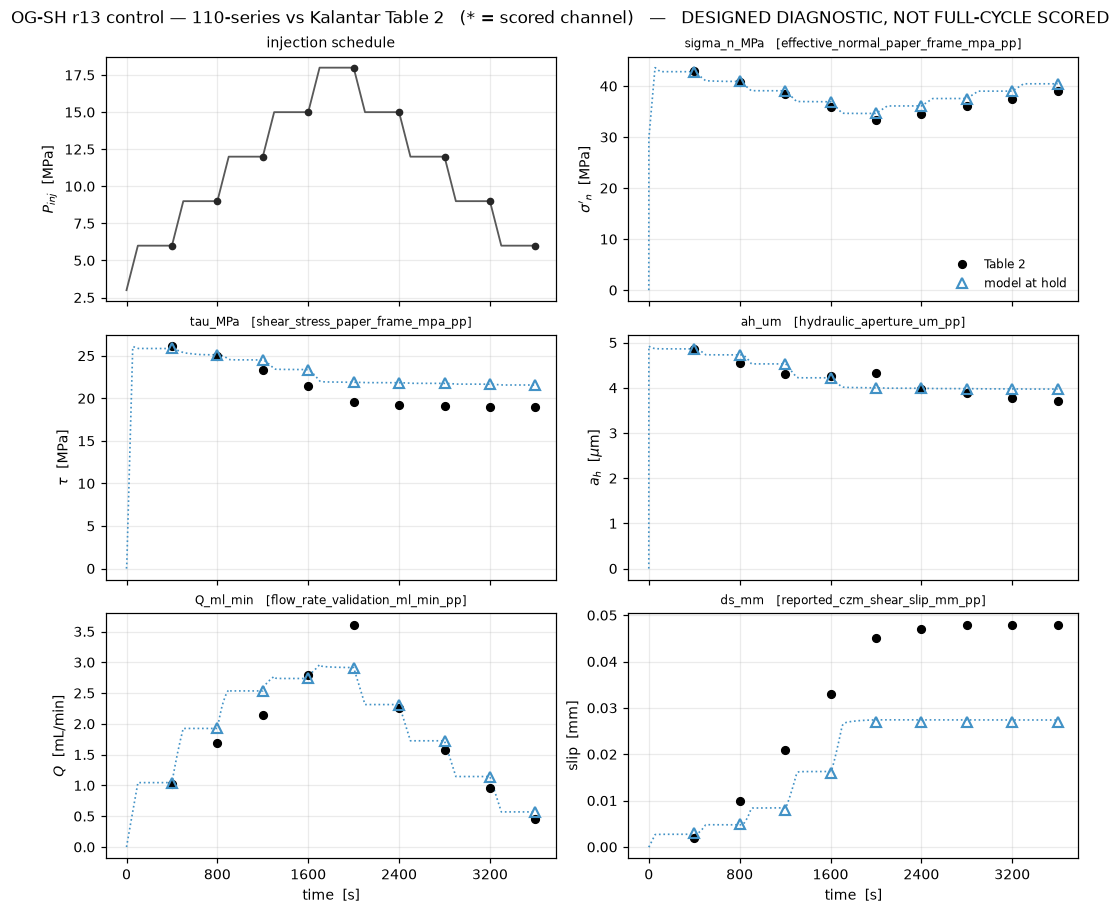

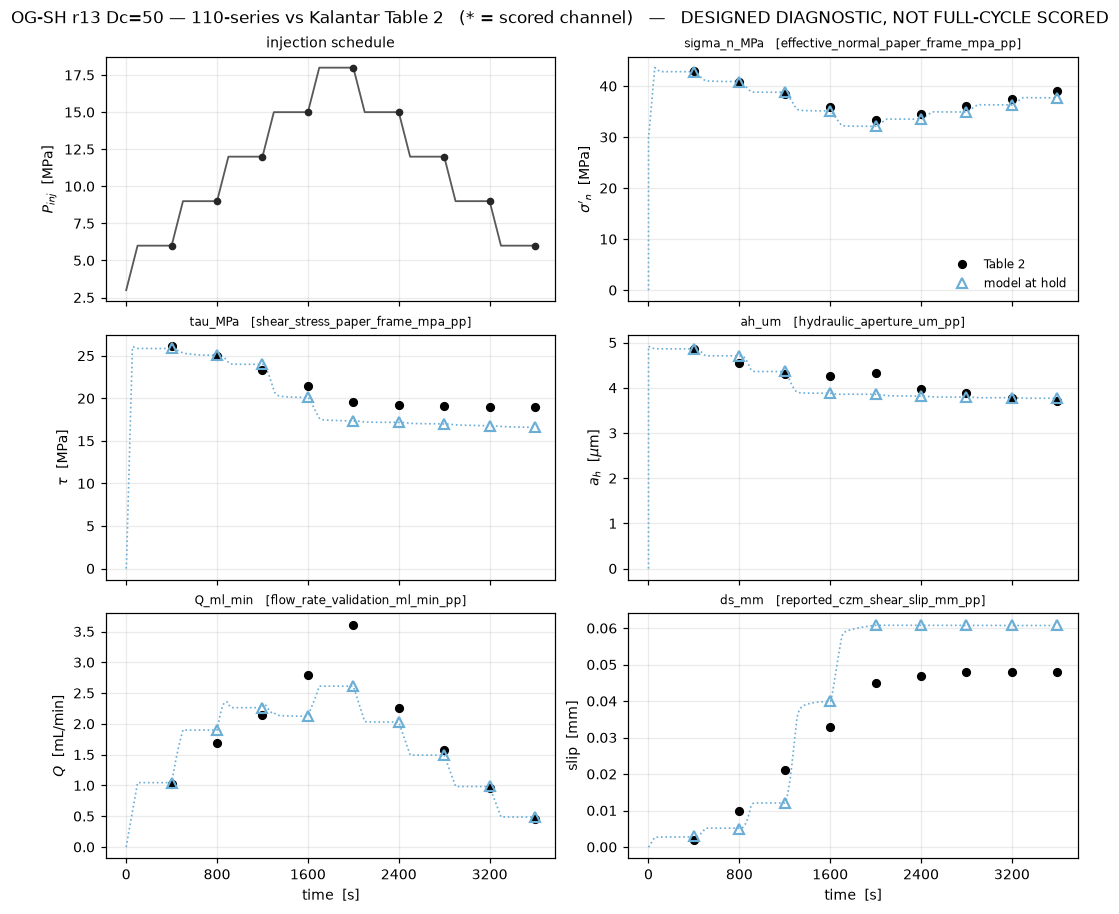

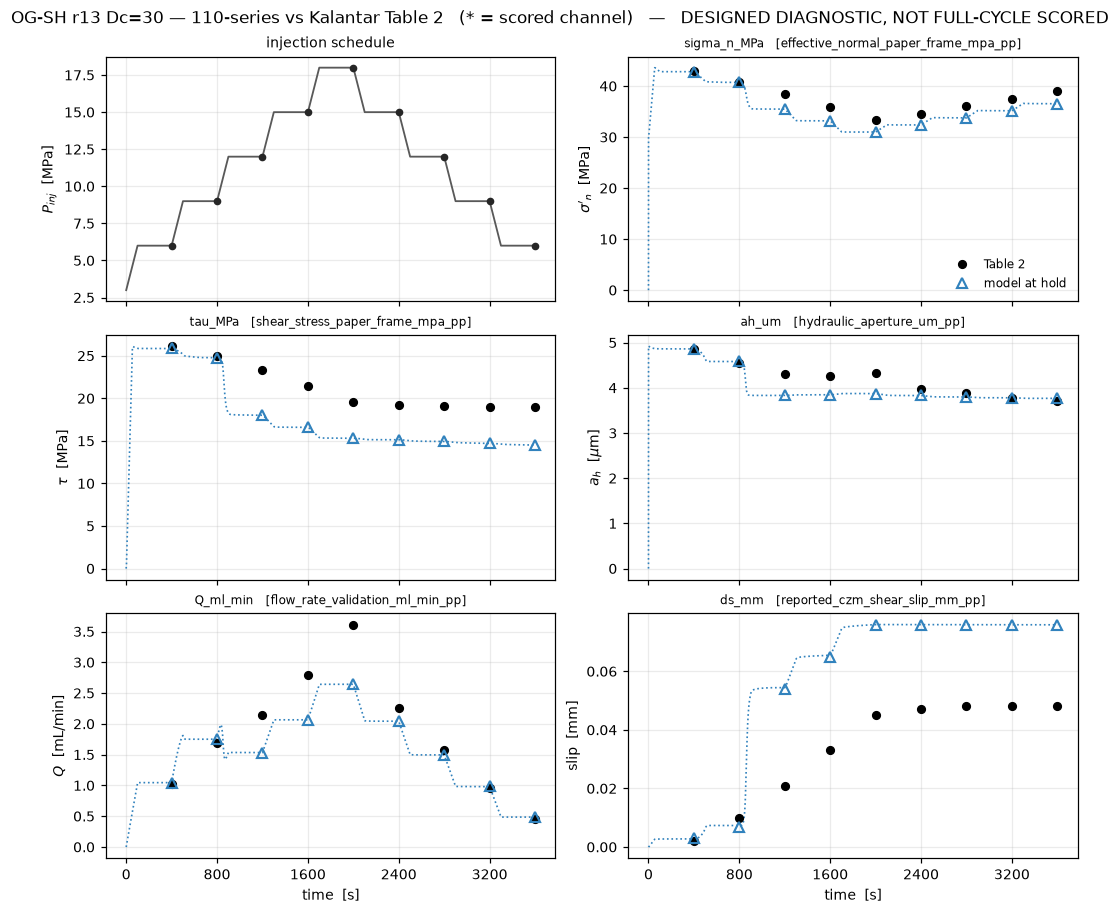

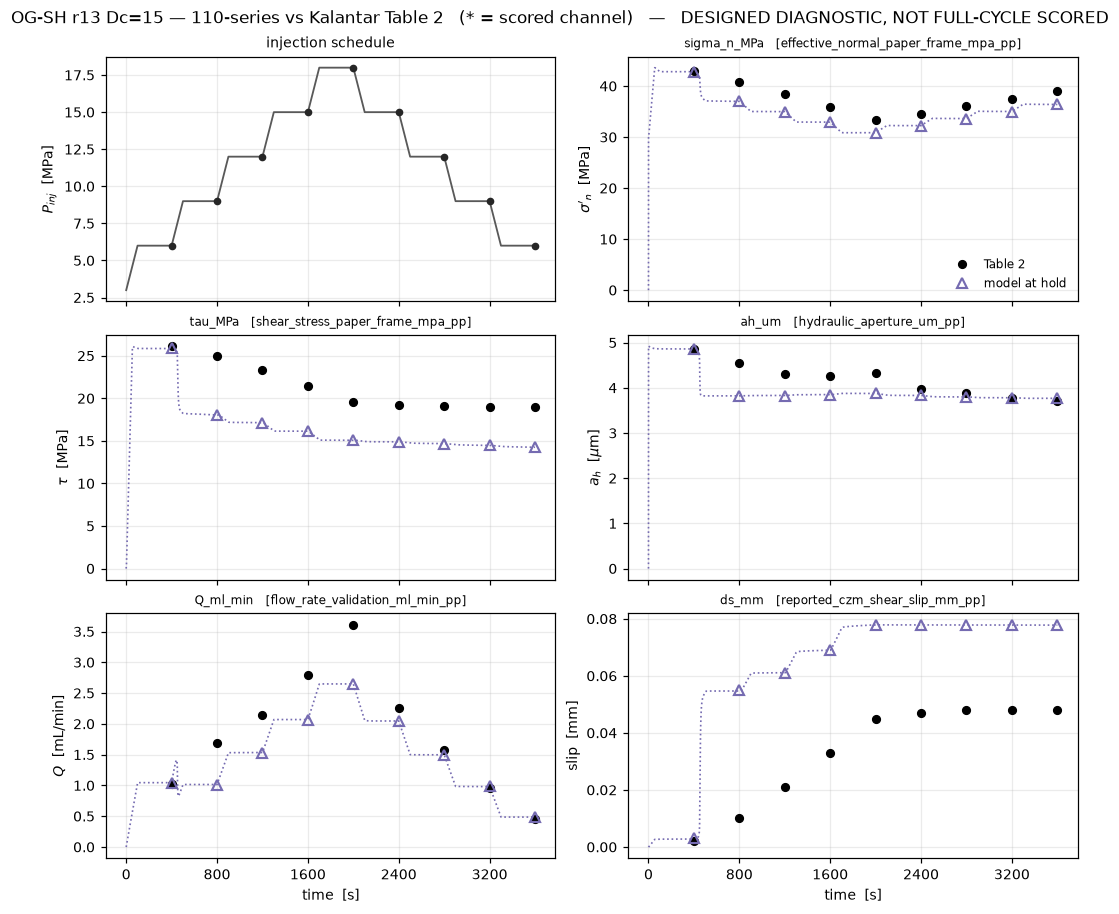

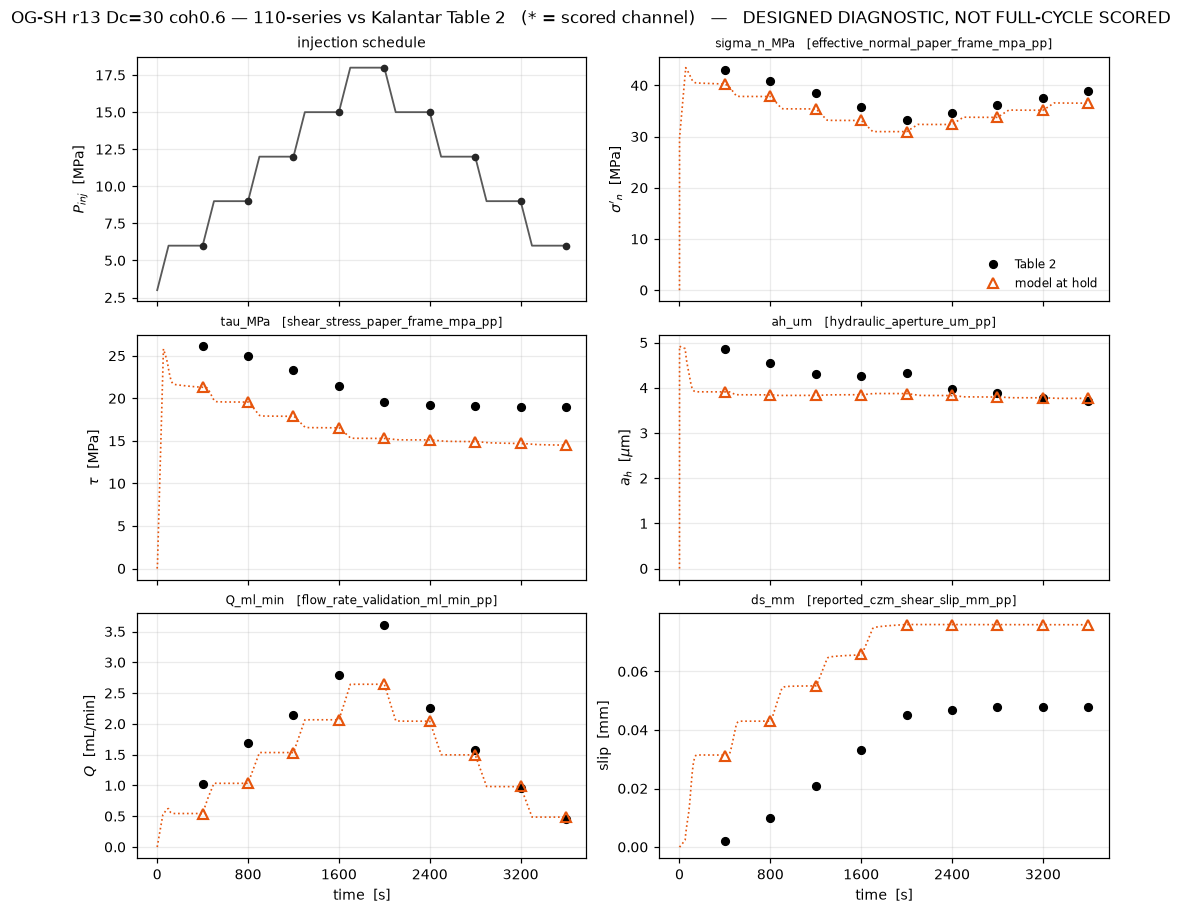

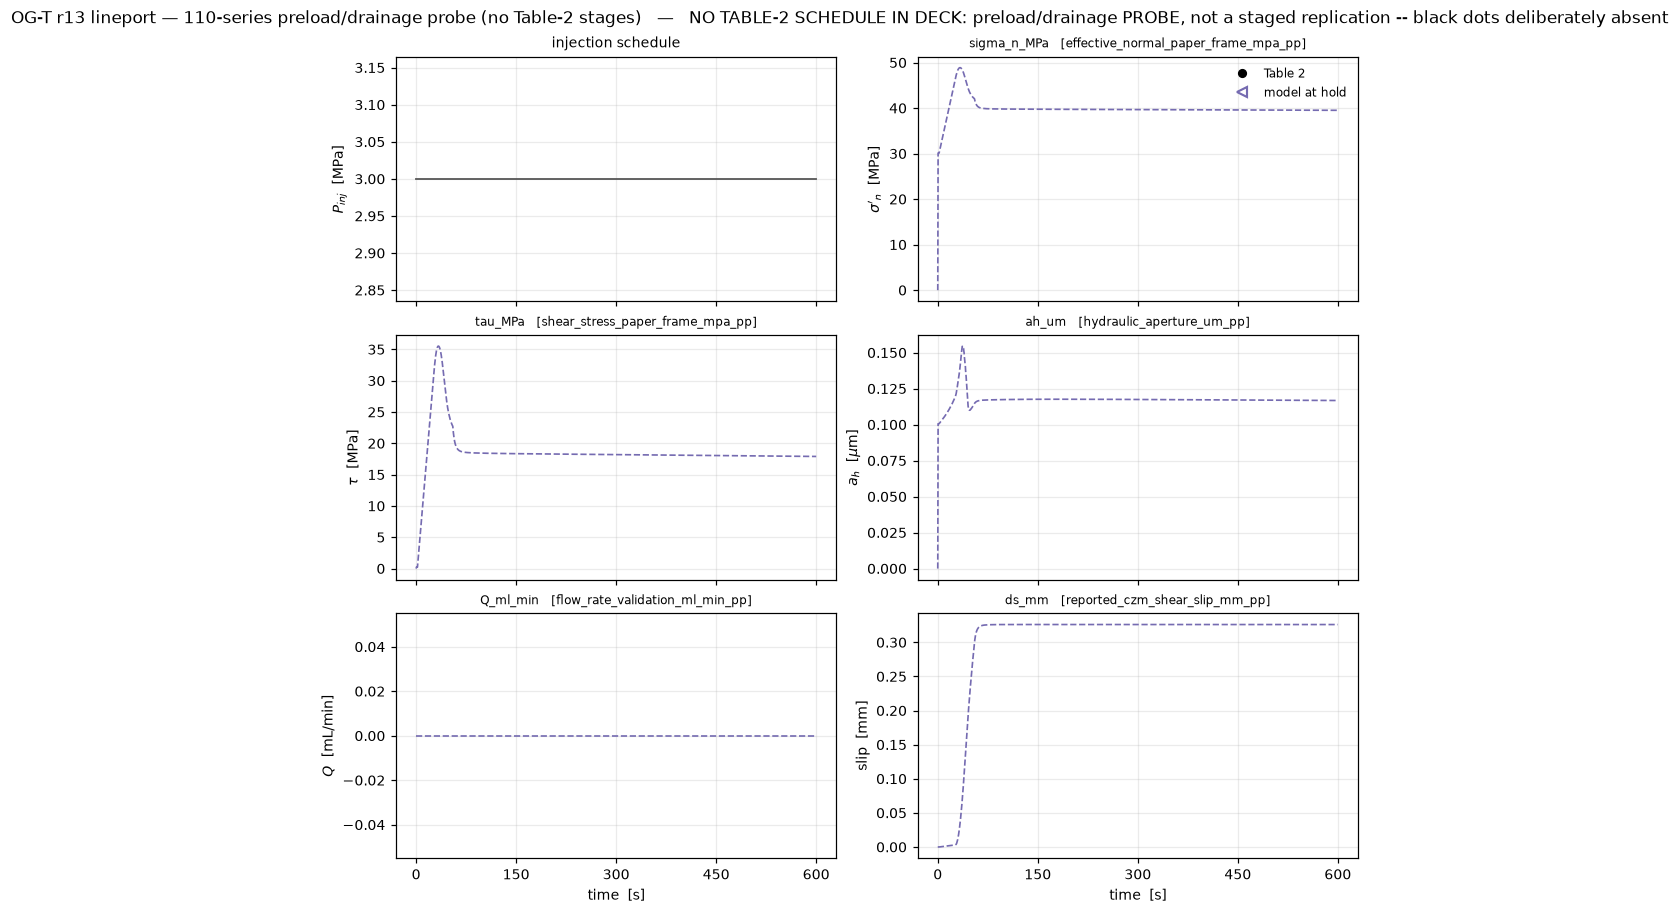

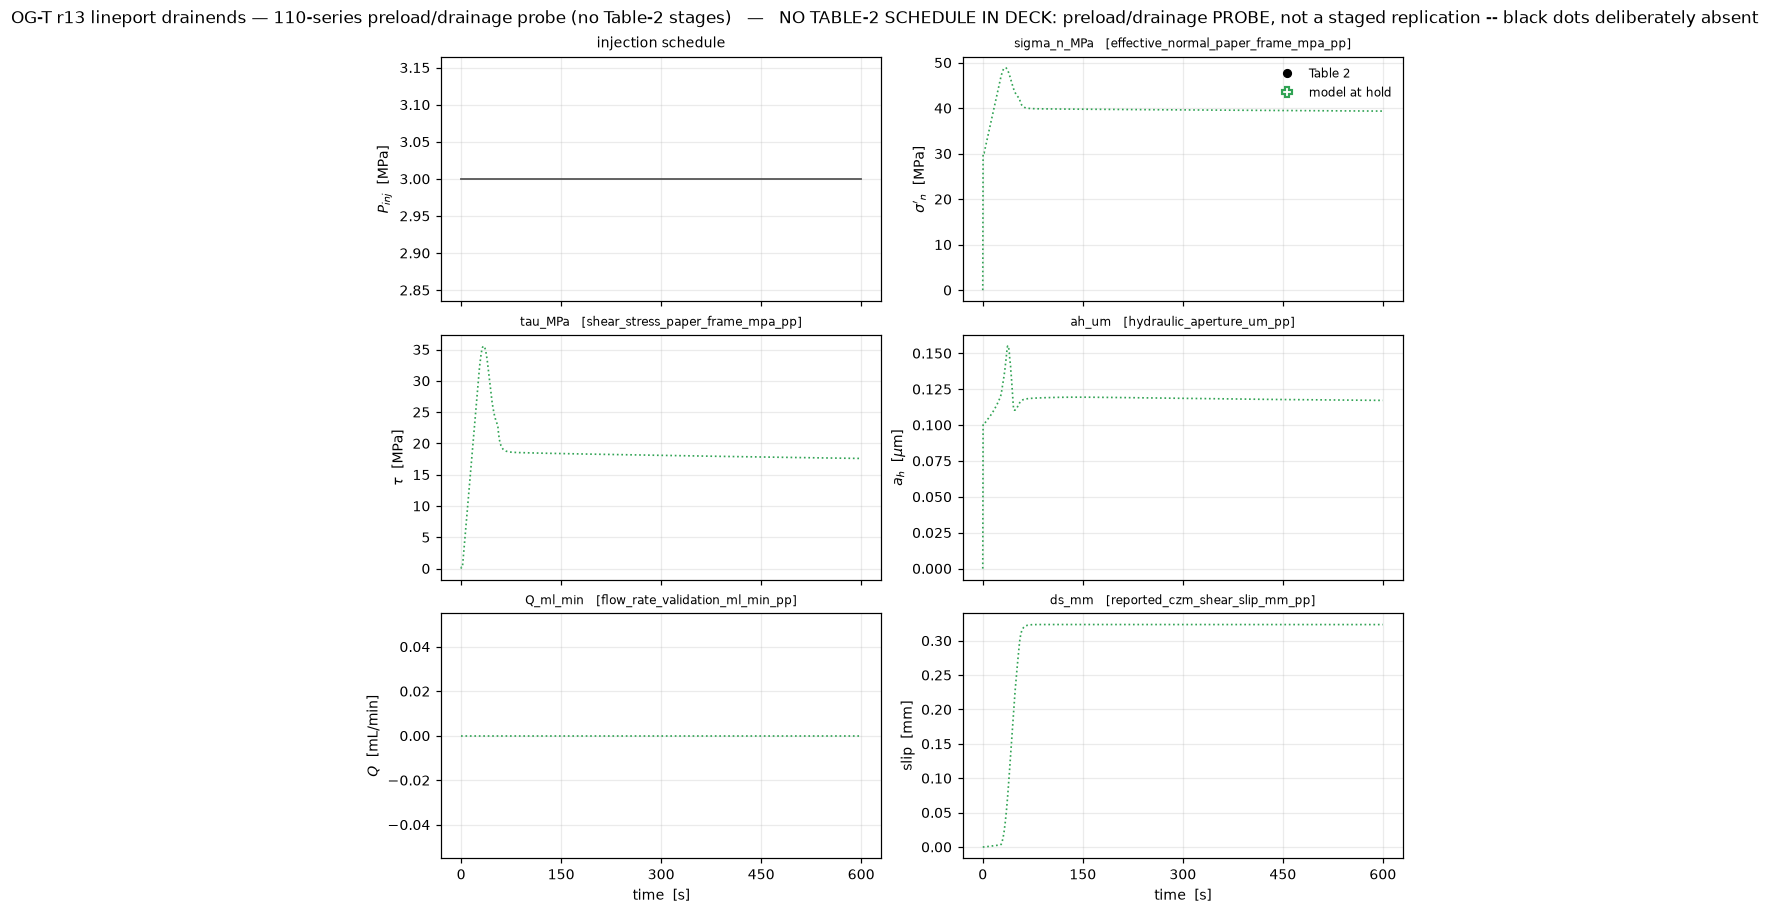

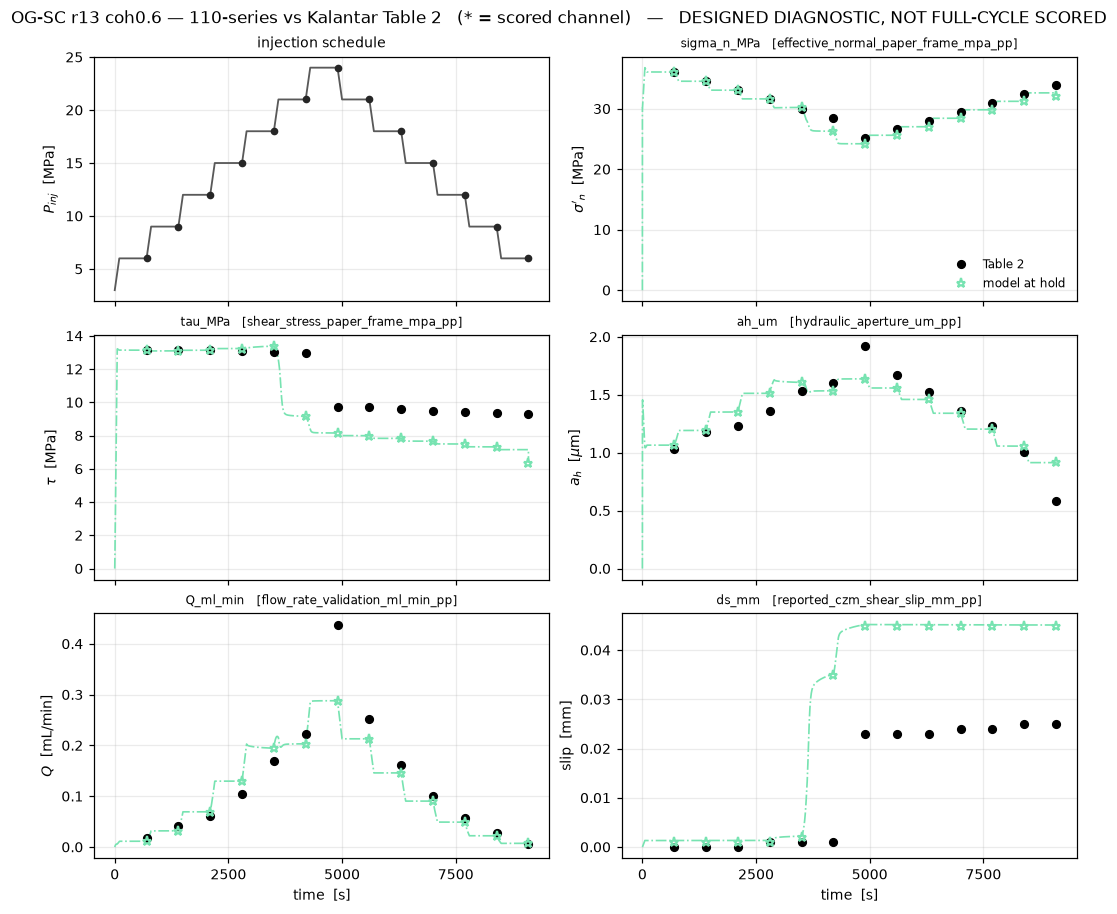

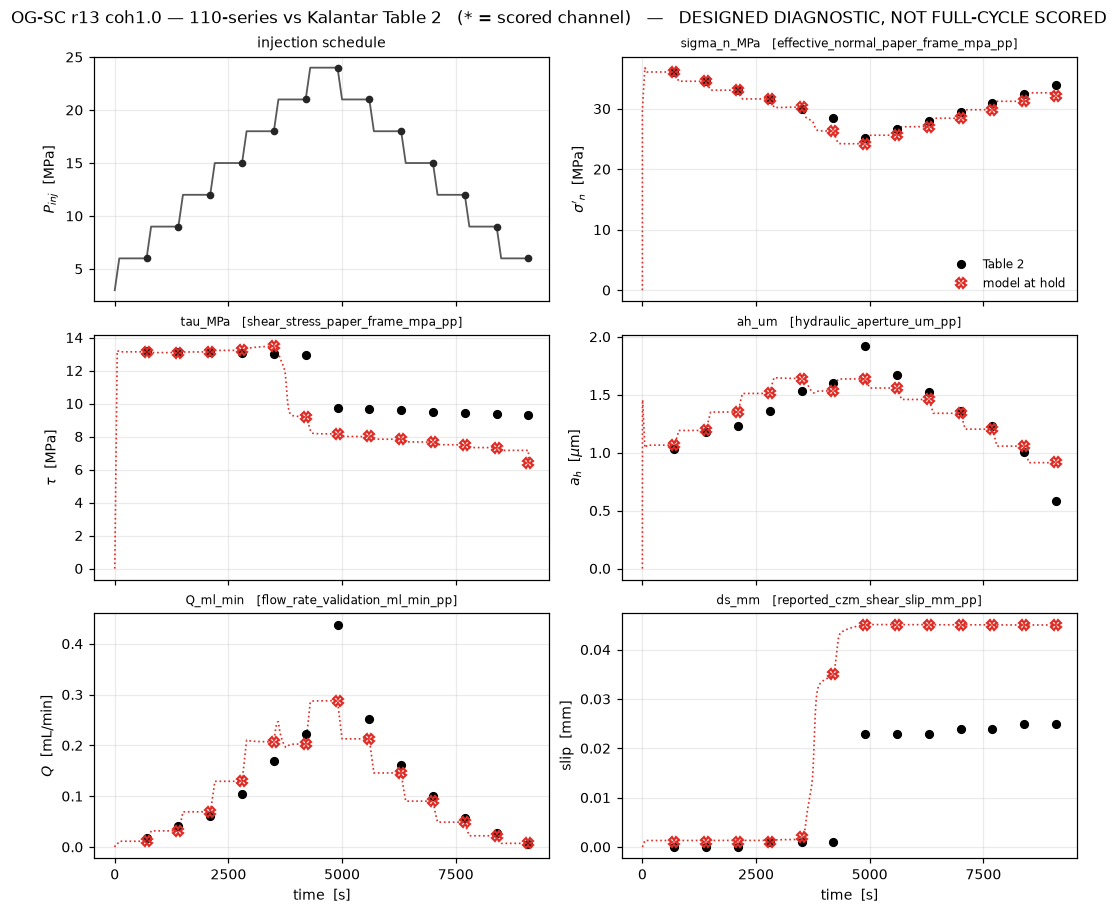

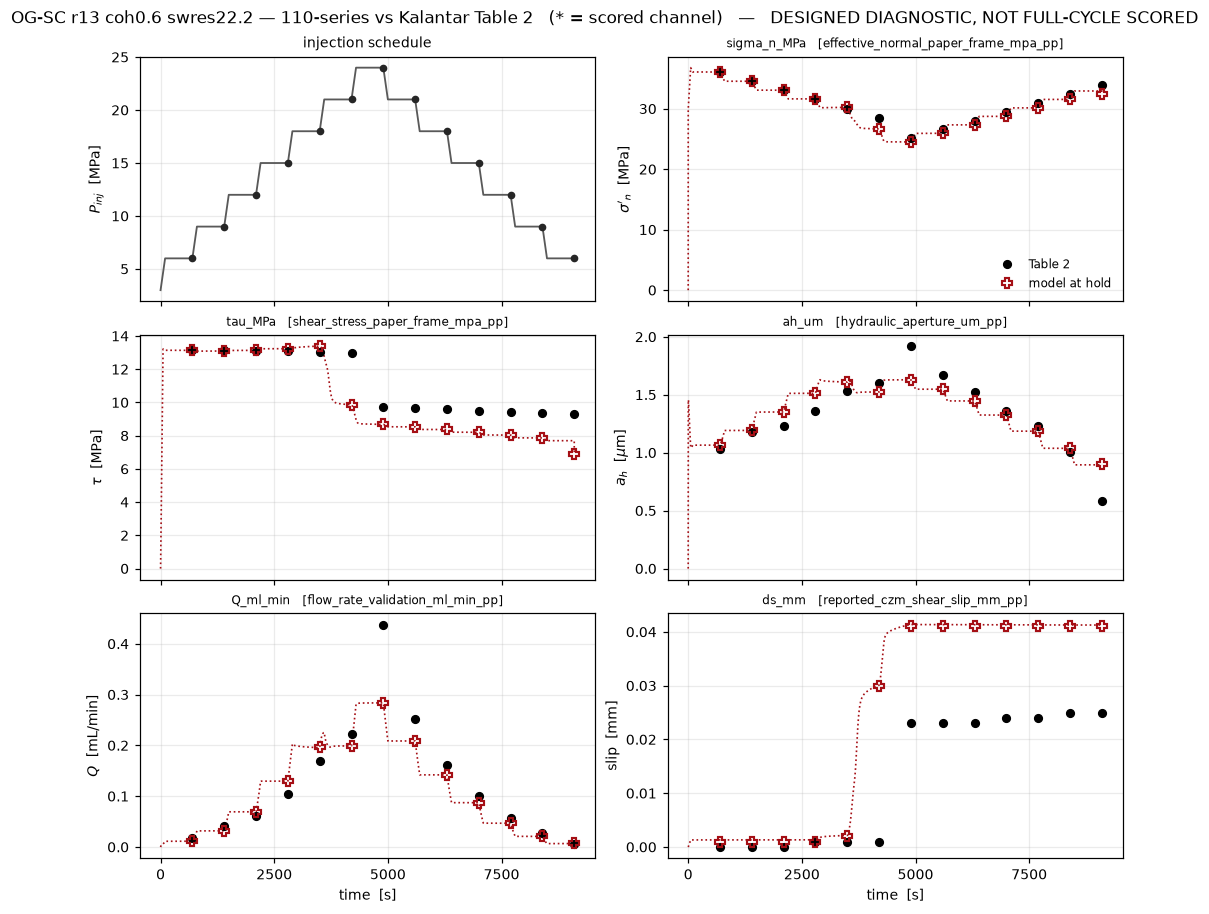

In [187]:
CHANNELS = [("sigma_n_MPa", "sn", r"$\sigma'_n$  [MPa]"),
            ("tau_MPa",     "tau", r"$\tau$  [MPa]"),
            ("ah_um",       "ah",  r"$a_h$  [$\mu$m]"),
            ("Q_ml_min",    "Q",   r"$Q$  [mL/min]"),
            ("ds_mm",       "ds",  r"slip  [mm]")]

def plot_channels(sample):
    cfg, tab = SHOWN[sample], STAGE_TABLES[sample]
    df, res = cfg["df"], SCORES.get(sample)
    scored = set(res["scored"]) if res else set()
    fig, axes = plt.subplots(3, 2, figsize=(9.5, 8.2), sharex=True)
    x, y = KG.parse_schedule(cfg["deck"])

    ax = axes.flat[0]
    ax.plot(x, y, color="0.35", lw=1.2)
    ax.plot(tab["t_s"], tab["Pi"], "o", ms=4, color="0.15")
    ax.set_ylabel(r"$P_{inj}$  [MPa]"); ax.set_title("injection schedule", fontsize=9)

    for ax, (key, label, ylab) in zip(axes.flat[1:], CHANNELS):
        series, name = KG.first_column(df, KG.KAL_COLUMNS[key])
        if series is not None:
            ax.plot(df["time"], series, lw=1.1, color=cfg["color"],
                    linestyle=cfg["linestyle"])
        ax.plot(tab["t_s"], tab[f"{label}_meas"], "o", ms=5, color="k",
                label="Table 2", zorder=5)
        ax.plot(tab["t_s"], tab[f"{label}_sim"], linestyle="none",
                marker=cfg["marker"], ms=6, mfc="none", mec=cfg["color"],
                mew=1.4, label="model at hold", zorder=6)
        star = " *" if key in scored else ""
        ax.set_ylabel(ylab)
        ax.set_title(f"{key}{star}" + (f"   [{name}]" if name else "   [not emitted]"),
                     fontsize=8)
        ax.xaxis.set_major_locator(MaxNLocator(5))
    axes.flat[1].legend(loc="best", fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("time  [s]")
    # Grey out the part of the schedule the run never reached, on every panel, so a
    # truncated run cannot be mistaken for a model that simply flattened out.
    if not cfg["complete"]:
        for ax in axes.flat:
            ax.axvspan(cfg["t_end"], cfg["end_time"], color="0.85", zorder=0)
            ax.axvline(cfg["t_end"], color="0.4", lw=0.9, ls=":")
    tag = (f"   —   INCOMPLETE at {cfg['t_end']:.0f} s ({cfg['pct']:.1f} %), NOT SCORED"
           if not cfg["complete"] else
           "   —   NO TABLE-2 SCHEDULE IN DECK: preload/drainage PROBE, not a staged "
           "replication -- black dots deliberately absent"
           if tab.attrs.get("no_schedule") else
           "   —   DESIGNED DIAGNOSTIC, NOT FULL-CYCLE SCORED"
           if cfg["scope"] == "diagnostic" else "")
    title = ("110-series preload/drainage probe (no Table-2 stages)"
              if tab.attrs.get("no_schedule") else
              "110-series vs Kalantar Table 2   (* = scored channel)")
    fig.suptitle(f"{sample} — {title}{tag}", fontsize=11)
    return fig

CHANNEL_FIGS = {s: plot_channels(s) for s in SHOWN}
plt.show()

### 8a. Run-to-run comparison

Each row overlays all available revisions for one specimen at the matched Table 2
holds. Truncated runs are visible, but the improvement table below uses only completed
runs and the same scored channels as the main scorecard. Lower mean nRMSE is better.

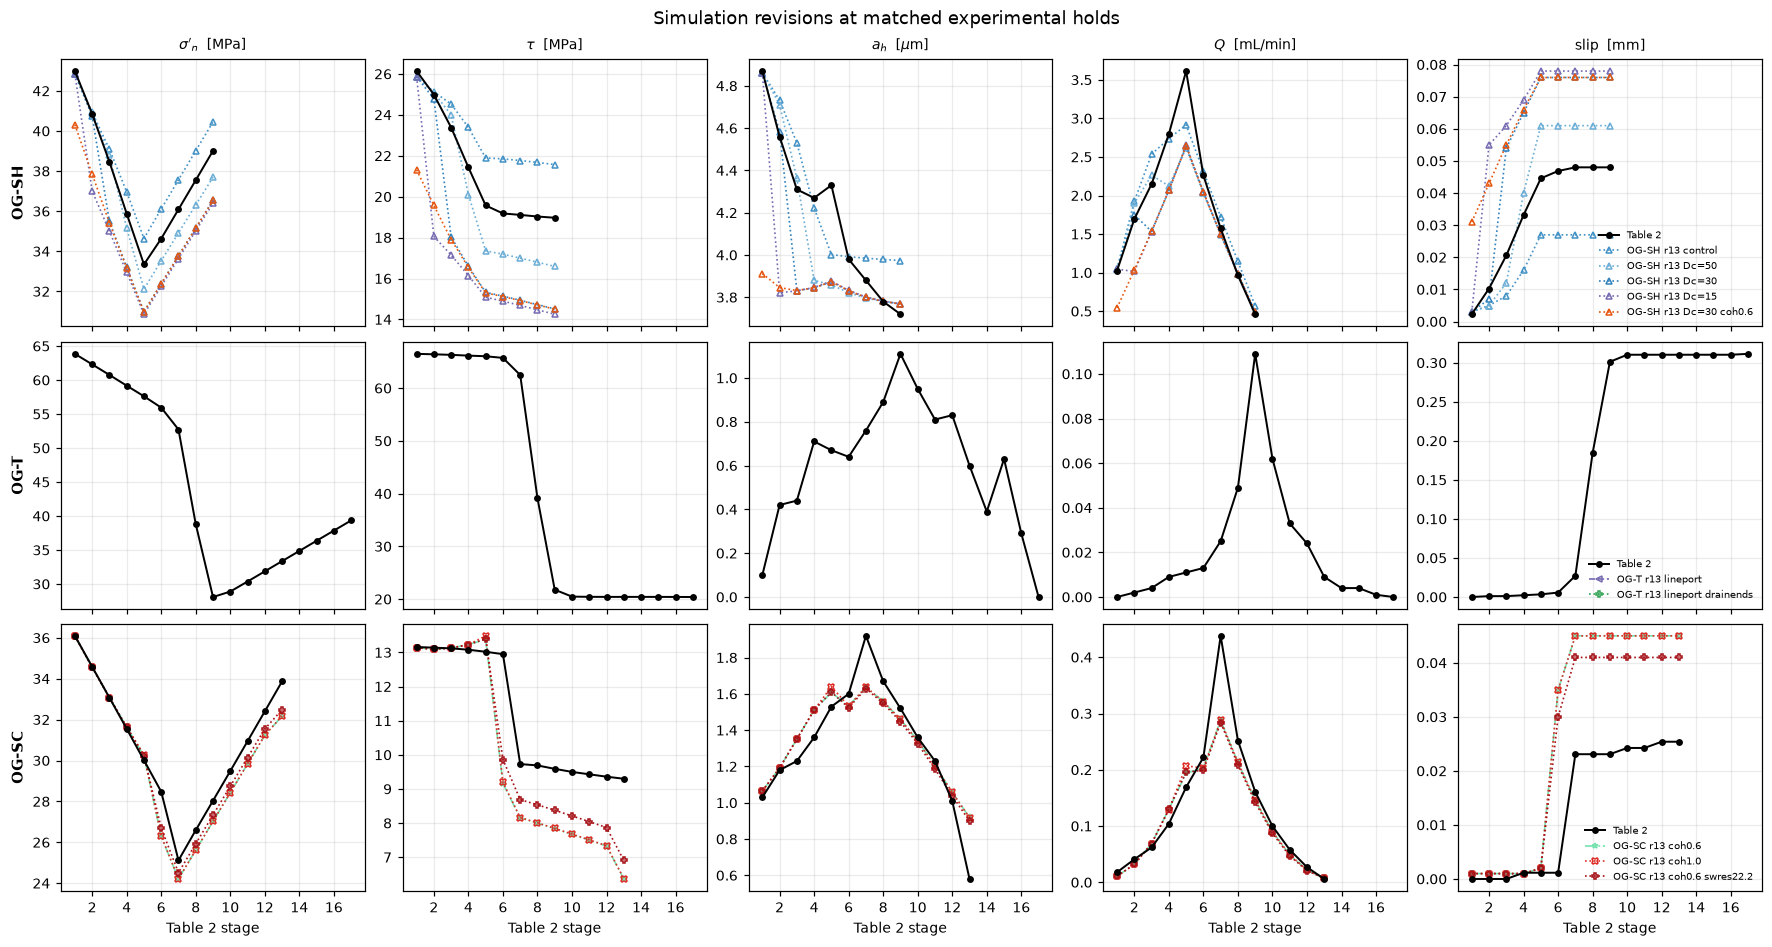

complete  mean_scored_nRMSE_pct  \
specimen run                                                            
OG-SH    OG-SH r13 control                True                    NaN   
         OG-SH r13 Dc=50                  True                    NaN   
         OG-SH r13 Dc=30                  True                    NaN   
         OG-SH r13 Dc=15                  True                    NaN   
         OG-SH r13 Dc=30 coh0.6           True                    NaN   
OG-T     OG-T r13 lineport                True                    NaN   
         OG-T r13 lineport drainends      True                    NaN   
OG-SC    OG-SC r13 coh0.6                 True                    NaN   
         OG-SC r13 coh1.0                 True                    NaN   
         OG-SC r13 coh0.6 swres22.2       True                    NaN   

                                      change_vs_previous_complete_pp  \
specimen run                                                           
OG-SH    OG-SH r13 control                                       NaN   
         OG-SH r13 Dc=50                                         NaN   
         OG-SH r13 Dc=30                                         NaN   
         OG-SH r13 Dc=15                                         NaN   
         OG-SH r13 Dc=30 coh0.6                                  NaN   
OG-T     OG-T r13 lineport                                       NaN   
         OG-T r13 lineport drainends                             NaN   
OG-SC    OG-SC r13 coh0.6                                        NaN   
         OG-SC r13 coh1.0                                        NaN   
         OG-SC r13 coh0.6 swres22.2                              NaN   

                                                    verdict  
specimen run                                                 
OG-SH    OG-SH r13 control            not full-cycle scored  
         OG-SH r13 Dc=50              not full-cycle scored  
         OG-SH r13 Dc=30              not full-cycle scored  
         OG-SH r13 Dc=15              not full-cycle scored  
         OG-SH r13 Dc=30 coh0.6       not full-cycle scored  
OG-T     OG-T r13 lineport            not full-cycle scored  
         OG-T r13 lineport drainends  not full-cycle scored  
OG-SC    OG-SC r13 coh0.6             not full-cycle scored  
         OG-SC r13 coh1.0             not full-cycle scored  
         OG-SC r13 coh0.6 swres22.2   not full-cycle scored

Change is current minus previous completed revision; negative means improvement.


In [188]:
COMPARE_CHANNELS = [("sn", "sigma_n_MPa", r"$\sigma'_n$  [MPa]"),
                    ("tau", "tau_MPa", r"$\tau$  [MPa]"),
                    ("ah", "ah_um", r"$a_h$  [$\mu$m]"),
                    ("Q", "Q_ml_min", r"$Q$  [mL/min]"),
                    ("ds", "ds_mm", r"slip  [mm]")]

fig, axes = plt.subplots(len(SPECIMENS), len(COMPARE_CHANNELS),
                         figsize=(16, 8.5), sharex=True, squeeze=False)
for row, specimen in enumerate(SPECIMENS):
    ref = REF[specimen]
    stages = ref["stage"].to_numpy()
    specimen_runs = [(run, cfg) for run, cfg in SHOWN.items()
                     if cfg["specimen"] == specimen]
    for col, (label, ref_key, ylab) in enumerate(COMPARE_CHANNELS):
        ax = axes[row, col]
        measured = ref[ref_key].to_numpy(dtype=float)
        if label == "ds":
            measured = measured / math.cos(math.radians(KG.THETA_DECK[specimen]))
        ax.plot(stages, measured, "-o", color="k", lw=1.3, ms=3.5,
                label="Table 2", zorder=5)
        for run, cfg in specimen_runs:
            tab = STAGE_TABLES[run]
            state = "" if cfg["complete"] else f" (truncated {cfg['pct']:.0f}%)"
            ax.plot(tab["stage"], tab[f"{label}_sim"],
                    color=cfg["color"], linestyle=cfg["linestyle"],
                    marker=cfg["marker"], mfc="none", lw=1.1, ms=4,
                    label=run + state)
        if row == 0:
            ax.set_title(ylab, fontsize=9)
        if col == 0:
            ax.set_ylabel(specimen, fontsize=10, fontweight="bold")
        if row == len(SPECIMENS) - 1:
            ax.set_xlabel("Table 2 stage")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[row, -1].legend(fontsize=6.5, loc="best")
fig.suptitle("Simulation revisions at matched experimental holds", fontsize=12)
plt.show()

# Quantify improvement only when a run is complete and was accepted by the scorecard.
comparison_rows, previous_complete = [], {}
for run, cfg in SHOWN.items():
    specimen = cfg["specimen"]
    res = SCORES.get(run)
    values = [] if res is None else [
        c["nrmse_pct"] for key, c in res["channels"].items()
        if key in res["scored"] and c is not None]
    mean_nrmse = float(np.mean(values)) if values else np.nan
    delta = np.nan
    verdict = "not full-cycle scored"
    if np.isfinite(mean_nrmse):
        if specimen not in previous_complete:
            verdict = "first completed baseline"
        else:
            delta = mean_nrmse - previous_complete[specimen]
            verdict = ("improved" if delta < -0.1 else
                       "worse" if delta > 0.1 else "unchanged (<0.1 pp)")
        previous_complete[specimen] = mean_nrmse
    comparison_rows.append(dict(specimen=specimen, run=run,
                                complete=cfg["complete"],
                                mean_scored_nRMSE_pct=mean_nrmse,
                                change_vs_previous_complete_pp=delta,
                                verdict=verdict))

comparison = pd.DataFrame(comparison_rows).set_index(["specimen", "run"])
display(comparison.round(2))
print("Change is current minus previous completed revision; negative means improvement.")

## 9. Stress path and the failure envelope

The experiment walks *down and left* in (σ'ₙ, τ) as injection raises pore pressure: σ'ₙ
falls, and τ falls too once the joint slips. Plotting the model's path against the
measurement together with the deck's own Barton–Bandis envelope shows immediately
whether a miss is a **loading** problem (path in the wrong place) or a **strength**
problem (path right, envelope wrong).

The envelope drawn is the deck's peak criterion
`tau = sigma'_n tan[phi_r + JRC log10(JCS/sigma'_n)] + c`, read straight out of the deck.

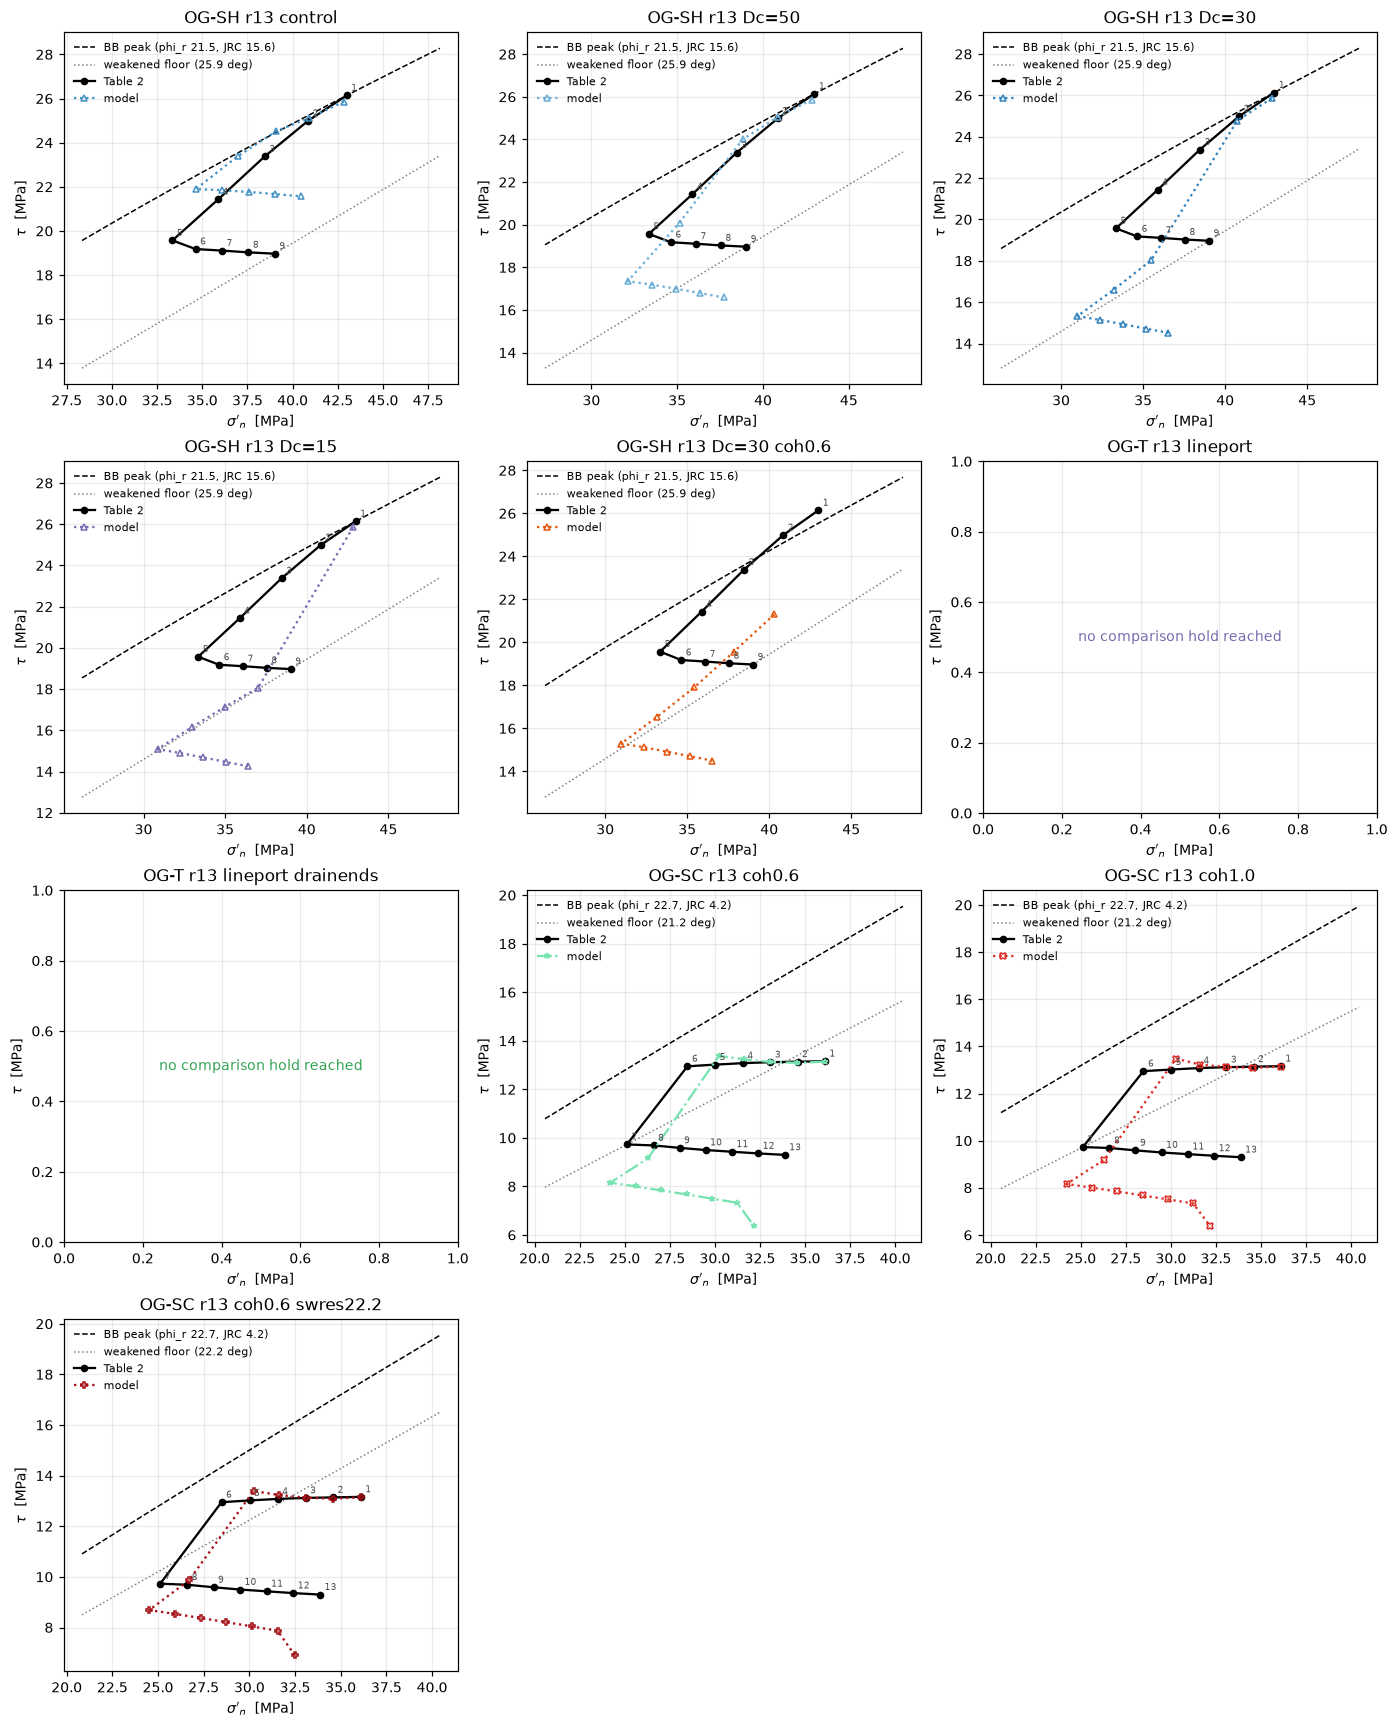

In [189]:
def deck_params(deck):
    t = deck.read_text()
    def grab(k, default=np.nan):
        m = re.search(rf"^\s+{k}\s*=\s*([0-9.eE+-]+)", t, re.M)
        return float(m.group(1)) if m else default
    return dict(jrc=grab("jrc"), jcs=grab("jcs"), phi_r=grab("residual_friction_angle_degrees"),
                cohesion=grab("cohesion", 0.0),
                phi_sw=grab("slip_weakening_residual_friction_angle_degrees"))

def bb_envelope(sn_mpa, p):
    sn = np.clip(sn_mpa, 1e-3, None)
    phi = p["phi_r"] + p["jrc"] * np.log10(p["jcs"] / 1e6 / sn)
    return sn * np.tan(np.radians(np.clip(phi, 0, 85))) + p["cohesion"] / 1e6

def run_grid(n, ncols=3):
    '''Create a compact grid and hide panels not occupied by a run.'''
    nplots = max(1, n)
    ncols = min(ncols, nplots)
    nrows = math.ceil(nplots / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.9 * nrows),
                             squeeze=False)
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    return fig, axes

fig, axes = run_grid(len(SHOWN))
for ax, s in zip(axes.flat, SHOWN):
    cfg = SHOWN[s]
    tab, p = STAGE_TABLES[s], deck_params(cfg["deck"])
    ax.set_xlabel(r"$\sigma'_n$  [MPa]"); ax.set_ylabel(r"$\tau$  [MPa]")
    ax.set_title(s if cfg["complete"] else f"{s}  (truncated, {cfg['pct']:.0f} %)")
    if tab.empty:
        ax.text(0.5, 0.5, "no comparison hold reached", ha="center", va="center",
                transform=ax.transAxes, color=cfg["color"])
        continue
    lo = min(tab["sn_meas"].min(), np.nanmin(tab["sn_sim"])) * 0.85
    hi = max(tab["sn_meas"].max(), np.nanmax(tab["sn_sim"])) * 1.12
    grid = np.linspace(lo, hi, 200)
    ax.plot(grid, bb_envelope(grid, p), "k--", lw=1.0,
            label=f"BB peak (phi_r {p['phi_r']:.1f}, JRC {p['jrc']:.1f})")
    ax.plot(grid, grid * np.tan(np.radians(p["phi_sw"])), ":", color="0.5", lw=1.0,
            label=f"weakened floor ({p['phi_sw']:.1f} deg)")
    ax.plot(tab["sn_meas"], tab["tau_meas"], "-o", ms=4, color="k", label="Table 2")
    ax.plot(tab["sn_sim"], tab["tau_sim"], ms=4, mfc="none",
            color=cfg["color"], linestyle=cfg["linestyle"], marker=cfg["marker"],
            label="model")
    for _, r in tab.iterrows():
        ax.annotate(int(r["stage"]), (r["sn_meas"], r["tau_meas"]), fontsize=6,
                    xytext=(3, 3), textcoords="offset points", color="0.3")
    ax.legend(fontsize=7, loc="upper left")
plt.show()

## 10. Aperture response

`a_h` against σ'ₙ, with the pressurisation and depressurisation branches drawn
separately. The **loop** is the informative part:

* **OG-SC and OG-T** open as σ'ₙ falls and close again — mostly reversible, with a
  residual offset.
* **OG-SH loses aperture monotonically** even though σ'ₙ *also* falls. A reversible
  closure law predicts the opposite sign, so that loss has to be irreversible — this is
  the paper's gouge result (§4.2: 12× OG-T's gouge mass), and in the deck it is carried
  by `slip_damage_scale`, the one term in the aperture law that subtracts.

If the model's loop is the right shape but the wrong height, the anchor
(`initial_hydraulic_aperture` at `reference_effective_normal_stress`) is off. If it is
flat when the measurement loops, the closure law is inert at these stresses.

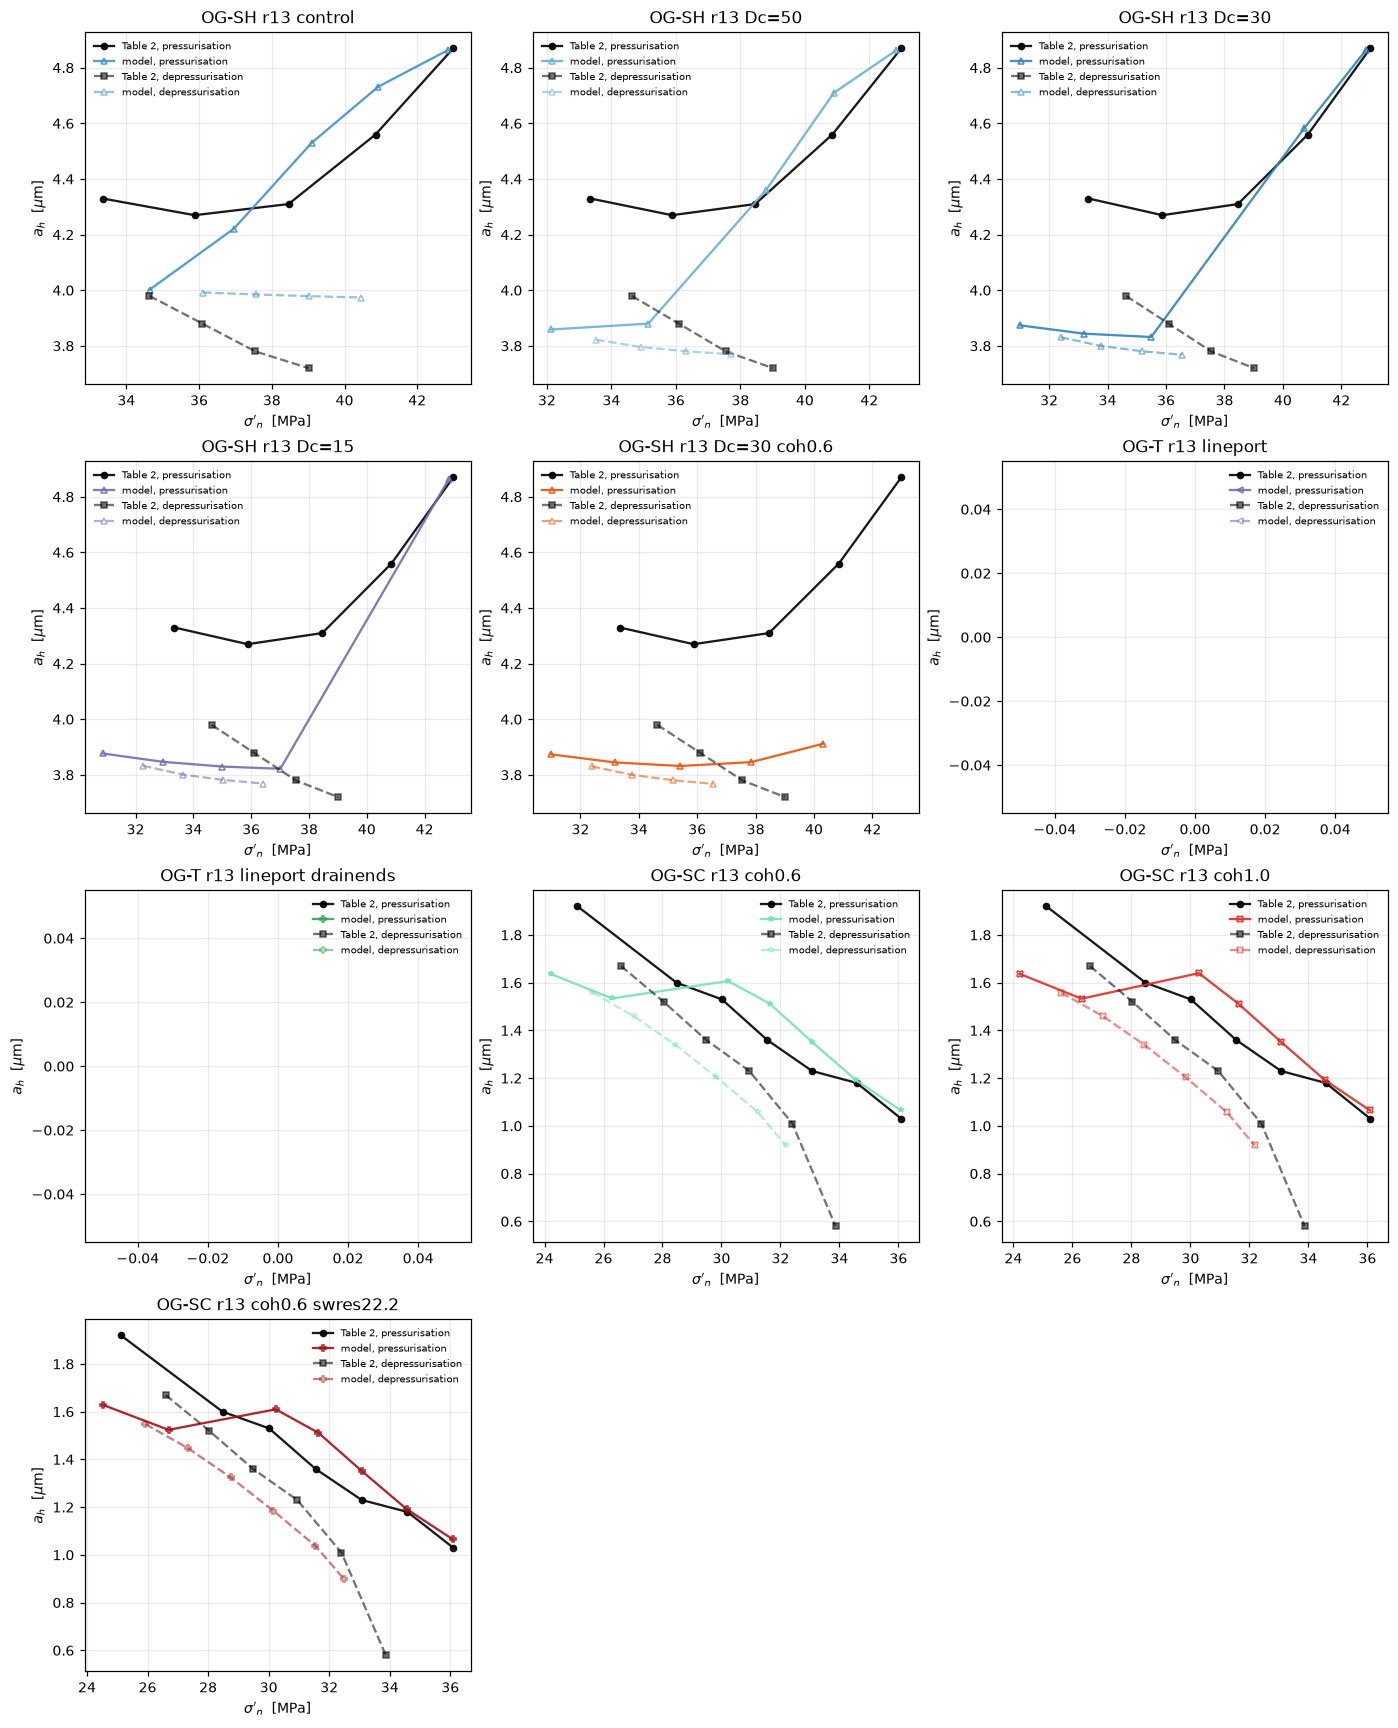

Measured a_h endpoints (stage 1 -> last):
  OG-SH   4.87 ->  3.72 um while sigma'_n went 42.99 -> 39.02 MPa
  OG-T    0.10 ->  0.00 um while sigma'_n went 63.86 -> 39.35 MPa
  OG-SC   1.03 ->  0.58 um while sigma'_n went 36.10 -> 33.87 MPa


In [190]:
fig, axes = run_grid(len(SHOWN))
for ax, s in zip(axes.flat, SHOWN):
    cfg, tab = SHOWN[s], STAGE_TABLES[s]
    ref = REF[cfg["specimen"]]
    br = ref["branch"].to_numpy()[:len(tab)]
    for mask, style, lab in [(br == "pressurization", "-o", "pressurisation"),
                             (br == "depressurization", "--s", "depressurisation")]:
        ax.plot(tab["sn_meas"][mask], tab["ah_meas"][mask], style, ms=4, color="k",
                label=f"Table 2, {lab}", alpha=0.9 if style == "-o" else 0.55)
        # Branch line style still communicates pressurisation/depressurisation;
        # the run's marker and color keep multiple model variants distinguishable.
        branch_ls = "-" if lab == "pressurisation" else "--"
        ax.plot(tab["sn_sim"][mask], tab["ah_sim"][mask], ms=4, mfc="none",
                linestyle=branch_ls, marker=cfg["marker"], color=cfg["color"],
                label=f"model, {lab}", alpha=0.9 if branch_ls == "-" else 0.55)
    ax.set_xlabel(r"$\sigma'_n$  [MPa]"); ax.set_ylabel(r"$a_h$  [$\mu$m]")
    ax.set_title(s if SHOWN[s]["complete"] else f"{s}  (truncated, {SHOWN[s]['pct']:.0f} %)")
    ax.legend(fontsize=6.5)
plt.show()

print("Measured a_h endpoints (stage 1 -> last):")
for s in SPECIMENS:
    r = REF[s]
    print(f"  {s:6s} {r['ah_um'].iloc[0]:5.2f} -> {r['ah_um'].iloc[-1]:5.2f} um "
          f"while sigma'_n went {r['sigma_n_MPa'].iloc[0]:5.2f} -> "
          f"{r['sigma_n_MPa'].iloc[-1]:5.2f} MPa")

## 11. Error summary

One panel per scored channel, stage on the x-axis. Reading it:

* a **flat offset** = a level error — loading gate, or an anchor constant;
* a **trend across stages** = a slope error — the constitutive law's stress dependence;
* a **step at one stage** = an event landing at the wrong time.

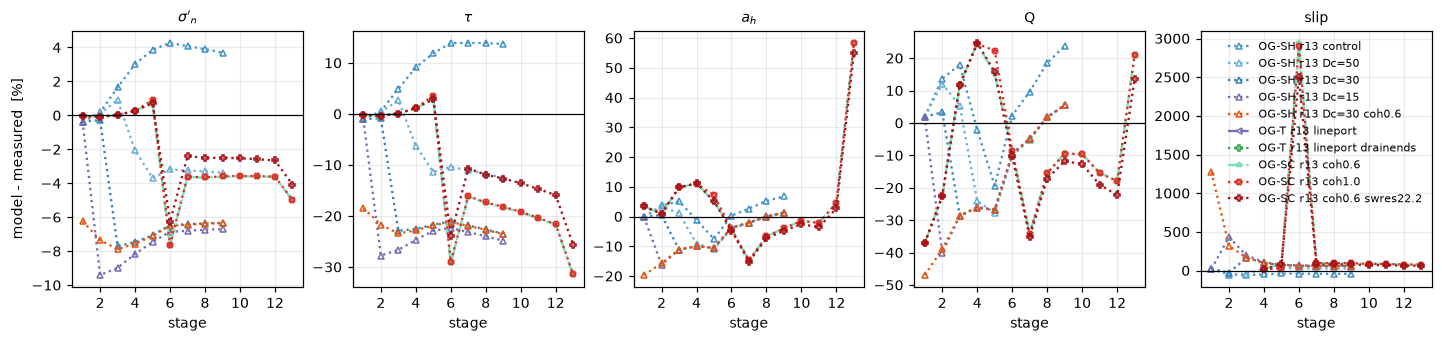

In [191]:
if STAGE_TABLES:
    labels = [("sn", r"$\sigma'_n$"), ("tau", r"$\tau$"), ("ah", r"$a_h$"),
              ("Q", "Q"), ("ds", "slip")]
    fig, axes = plt.subplots(1, len(labels), figsize=(2.6 * len(labels), 3.0), sharex=True)
    for ax, (lab, title) in zip(axes, labels):
        for s, tab in STAGE_TABLES.items():
            cfg = SHOWN[s]
            ax.plot(tab["stage"], tab[f"{lab}_err%"], ms=3.5,
                    color=cfg["color"], linestyle=cfg["linestyle"],
                    marker=cfg["marker"], mfc="none", label=s)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(title, fontsize=9); ax.set_xlabel("stage")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].set_ylabel("model - measured  [%]")
    axes[-1].legend(fontsize=7)
    plt.show()

## 12. Round 6–10 preregistered checks

These checks implement the pass bands written in the deck headers *before* the runs.
A diagnostic is judged only at its designed horizon; it is never promoted into the
full-cycle scorecard. `cumulative_plastic_slip_pp` is converted from metres to µm.
For OG-SC, a macroscopic burst is operationally a stage-to-stage plastic-slip jump
greater than 10 µm. The OG-SC header calls `tau_6` “near 12.95 MPa” without specifying
a tolerance, so the table reports its signed error but does not invent a pass band.

Round 10's OG-SH headers require completion, finite stage-9 output, stage-5 slip of
30–60 µm, and stage-5 τ ≤ 21.14 MPa. They do not define a numerical runaway
threshold, so that condition is not reverse-engineered from a truncated trajectory. If a
run does not reach stage 5, its physical outcome checks are reported as not evaluable.

In [192]:
# DISABLED -- needs Round 6-10 historical entries uncommented in RUNS (cell 8).
# Uncomment both this cell and those RUNS blocks together to reactivate.
# def mean_scored_nrmse(run):
#     res = SCORES[run]
#     vals = [c["nrmse_pct"] for key, c in res["channels"].items()
#             if key in res["scored"] and c is not None]
#     return float(np.mean(vals))

# def raw_hold(run, stage):
#     cfg, tab = SHOWN[run], STAGE_TABLES[run]
#     t = float(tab.loc[tab.stage == stage, "t_s"].iloc[0])
#     return cfg["df"][cfg["df"].time <= t + 1e-9].iloc[-1]

# # Round 6: full-cycle score changes and the two preregistered outcome gates.
# sh5 = STAGE_TABLES["OG-SH r6"].query("stage == 5").iloc[0]
# sh5_slip_um = float(raw_hold("OG-SH r6", 5).reported_czm_shear_slip_mm_pp * 1e3)
# sh5_tau_err = 100 * (sh5.tau_sim - sh5.tau_meas) / sh5.tau_meas
# sc_plastic = {stage: raw_hold("OG-SC r6", stage).cumulative_plastic_slip_pp * 1e6
#               for stage in range(1, 8)}
# sc_burst = next((stage for stage in range(2, 8)
#                  if sc_plastic[stage] - sc_plastic[stage - 1] > 10.0), None)
# round6 = pd.DataFrame([
#     dict(specimen="OG-SH", mean_nRMSE=mean_scored_nrmse("OG-SH r6"),
#          change_vs_r5_pp=mean_scored_nrmse("OG-SH r6") - mean_scored_nrmse("OG-SH r5"),
#          key_result=f"stage-5 slip {sh5_slip_um:.2f} um; tau error {sh5_tau_err:+.2f}%",
#          gate_pass=30 <= sh5_slip_um <= 60 and sh5_tau_err < 8),
#     dict(specimen="OG-SC", mean_nRMSE=mean_scored_nrmse("OG-SC r6"),
#          change_vs_r5_pp=mean_scored_nrmse("OG-SC r6") - mean_scored_nrmse("OG-SC r5"),
#          key_result=f"stage-5 plastic {sc_plastic[5]:.2f} um; first burst stage {sc_burst}",
#          gate_pass=sc_plastic[5] <= 2 and sc_burst == 7),
# ]).set_index("specimen")
# display(round6.round(3))

In [193]:
# DISABLED -- needs Round 6-10 historical entries uncommented in RUNS (cell 8).
# Uncomment both this cell and those RUNS blocks together to reactivate.
# # Round 7 run health: both k_t diagnostics failed before their first Table-2 hold.
# round7_health = []
# for run in ["OG-SH r7 k_t probe", "OG-SC r7 k_t probe"]:
#     cfg = SHOWN[run]
#     round7_health.append(dict(
#         run=run, rows=len(cfg["df"]), t_end_s=cfg["t_end"],
#         designed_end_s=cfg["end_time"], pct=cfg["pct"],
#         reached_holds=len(STAGE_TABLES[run]),
#         verdict="INCONCLUSIVE -- failed before first hold"))
# display(pd.DataFrame(round7_health).set_index("run").round(3))

# # OG-T preload probes need a different gate because they stop before injection.
# OGT_PROBES = {
#     "r6 26-deg displacement": STUDY_DIR / "OGT/results_csv_hpc/110_14_og_t_preload_probe_hpc.csv",
#     "r7 28-deg traction": STUDY_DIR / "OGT/results_csv_hpc/110_16_og_t_traction_probe_r7_hpc.csv",
# }
# probe_rows = []
# for name, path in OGT_PROBES.items():
#     df = (pd.read_csv(path).sort_values("time")
#           .drop_duplicates("time", keep="last").reset_index(drop=True))
#     elastic = df[(df.time >= 2) & (df.cumulative_plastic_slip_pp <= 1e-12)]
#     paper = elastic.effective_normal_paper_frame_mpa_pp.to_numpy(float)
#     law = elastic.bb_effective_normal_stress_pp.to_numpy(float) / 1e6
#     slope = np.polyfit(paper, law, 1)[0]
#     disagreement = 100 * abs(law[-1] - paper[-1]) / abs(paper[-1])
#     plastic_end = float(df.cumulative_plastic_slip_pp.iloc[-1] * 1e6)
#     probe_rows.append(dict(
#         probe=name, t_end_s=df.time.iloc[-1], plastic_slip_end_um=plastic_end,
#         elastic_normal_slope=slope, last_elastic_disagreement_pct=disagreement,
#         no_plastic_slip=plastic_end <= 0.1, positive_unit_slope=0.8 <= slope <= 1.2,
#         normal_channels_within_5pct=disagreement <= 5,
#         gate_pass=(plastic_end <= 0.1 and 0.8 <= slope <= 1.2 and disagreement <= 5)))
# display(pd.DataFrame(probe_rows).set_index("probe").round(3))

In [194]:
# DISABLED -- needs Round 6-10 historical entries uncommented in RUNS (cell 8).
# Uncomment both this cell and those RUNS blocks together to reactivate.
# # Round 8 OG-SH: weakening-exponent bracket through stage 5.
# sh_rows = []
# for run in ["OG-SH r8 exp 1.20", "OG-SH r8 exp 1.60"]:
#     h = STAGE_TABLES[run].query("stage == 5").iloc[0]
#     slip_um = float(raw_hold(run, 5).reported_czm_shear_slip_mm_pp * 1e3)
#     sh_rows.append(dict(
#         run=run, completed=SHOWN[run]["complete"], stage5_slip_um=slip_um,
#         stage5_tau_MPa=h.tau_sim, tau_limit_MPa=21.14,
#         slip_30_to_60_um=30 <= slip_um <= 60, tau_at_or_below_limit=h.tau_sim <= 21.14,
#         gate_pass=SHOWN[run]["complete"] and 30 <= slip_um <= 60 and h.tau_sim <= 21.14))
# display(pd.DataFrame(sh_rows).set_index("run").round(3))

# # Round 8 OG-SC: pressure-coupling bracket through stage 7.
# sc_rows = []
# for run in ["OG-SC r8 pcoeff 0.80", "OG-SC r8 pcoeff 0.84"]:
#     h6 = STAGE_TABLES[run].query("stage == 6").iloc[0]
#     h7 = STAGE_TABLES[run].query("stage == 7").iloc[0]
#     p6 = float(raw_hold(run, 6).cumulative_plastic_slip_pp * 1e6)
#     p7 = float(raw_hold(run, 7).cumulative_plastic_slip_pp * 1e6)
#     slip7 = float(raw_hold(run, 7).reported_czm_shear_slip_mm_pp * 1e3)
#     preburst_ok = p6 <= 2
#     burst7 = p7 - p6 > 10
#     slip_ok = 18 <= slip7 <= 28
#     aperture_ok = 1.50 <= h6.ah_sim <= 1.70
#     sc_rows.append(dict(
#         run=run, completed=SHOWN[run]["complete"], plastic_stage6_um=p6,
#         burst_increment_stage7_um=p7-p6, stage7_slip_um=slip7,
#         tau6_MPa=h6.tau_sim, tau6_error_MPa=h6.tau_sim-12.95, ah6_um=h6.ah_sim,
#         held_through_stage6=preburst_ok, burst_at_stage7=burst7,
#         slip_18_to_28_um=slip_ok, ah6_1p50_to_1p70_um=aperture_ok,
#         gate_pass=SHOWN[run]["complete"] and preburst_ok and burst7 and slip_ok and aperture_ok))
# display(pd.DataFrame(sc_rows).set_index("run").round(3))

# # Round 9: keep the four submitted arms explicit, including missing/incomplete results.
# round9_runs = ["OG-T r8 graded preload", "OG-SC r9 paper mean",
#                "OG-SH r9 RSF direct", "OG-SH r9 RSF aging"]
# round9_health = []
# for run in round9_runs:
#     cfg = RUNS[run]
#     if run not in SHOWN:
#         round9_health.append(dict(run=run, state="MISSING CSV", rows=0,
#                                   t_end_s=np.nan, designed_end_s=deck_end_time(cfg["deck"]),
#                                   reached_holds=0))
#         continue
#     shown = SHOWN[run]
#     state = ("diagnostic complete" if shown["complete"] else
#              f"INCOMPLETE {shown['pct']:.1f}%")
#     round9_health.append(dict(run=run, state=state, rows=len(shown["df"]),
#                               t_end_s=shown["t_end"], designed_end_s=shown["end_time"],
#                               reached_holds=len(STAGE_TABLES[run])))
# display(pd.DataFrame(round9_health).set_index("run").round(3))

# # Round 10: keep all planned full-cycle arms explicit, including missing results.
# round10_runs = ["OG-T r10 graded full", "OG-SH r10 RSF b=0.002",
#                 "OG-SH r10 RSF b=0.004"]
# round10_health = []
# for run in round10_runs:
#     cfg = RUNS[run]
#     if run not in SHOWN:
#         round10_health.append(dict(run=run, state="PENDING CSV", rows=0,
#                                    t_end_s=np.nan, designed_end_s=deck_end_time(cfg["deck"]),
#                                    reached_holds=0))
#         continue
#     shown = SHOWN[run]
#     state = ("diagnostic complete" if shown["complete"] else
#              f"INCOMPLETE {shown['pct']:.1f}%")
#     round10_health.append(dict(run=run, state=state, rows=len(shown["df"]),
#                                t_end_s=shown["t_end"], designed_end_s=shown["end_time"],
#                                reached_holds=len(STAGE_TABLES[run])))
# display(pd.DataFrame(round10_health).set_index("run").round(3))

# # Round 10 OG-SH preregistered gates. Missing stages stay NaN: an incomplete run
# # must fail the completion gate without being assigned invented physical outcomes.
# r10_sh_rows = []
# for run in ["OG-SH r10 RSF b=0.002", "OG-SH r10 RSF b=0.004"]:
#     if run not in SHOWN:
#         r10_sh_rows.append(dict(
#             run=run, state="MISSING CSV", t_end_s=np.nan, completion_pct=np.nan,
#             reached_holds=0, finite_to_last_row=np.nan, stage5_slip_um=np.nan,
#             stage5_tau_MPa=np.nan, reached_stage9=False, physical_checks="NOT EVALUABLE",
#             gate_pass=False))
#         continue
#     shown, tab = SHOWN[run], STAGE_TABLES[run]
#     numeric = shown["df"].select_dtypes(include=[np.number]).to_numpy()
#     finite = bool(np.isfinite(numeric).all())
#     stage5 = tab.query("stage == 5")
#     stage9 = tab.query("stage == 9")
#     if stage5.empty:
#         slip5 = tau5 = np.nan
#         physical = "NOT EVALUABLE -- stage 5 not reached"
#         physical_pass = False
#     else:
#         slip5 = float(raw_hold(run, 5).reported_czm_shear_slip_mm_pp * 1e3)
#         tau5 = float(stage5.iloc[0].tau_sim)
#         physical_pass = 30 <= slip5 <= 60 and tau5 <= 21.14
#         physical = f"{'PASS' if physical_pass else 'FAIL'}: slip and tau gates"
#     reached9 = not stage9.empty
#     gate_pass = bool(shown["complete"] and reached9 and finite and physical_pass)
#     state = "complete" if shown["complete"] else f"INCOMPLETE {shown['pct']:.1f}%"
#     r10_sh_rows.append(dict(
#         run=run, state=state, t_end_s=shown["t_end"], completion_pct=shown["pct"],
#         reached_holds=len(tab), finite_to_last_row=finite, stage5_slip_um=slip5,
#         stage5_tau_MPa=tau5, reached_stage9=reached9, physical_checks=physical,
#         gate_pass=gate_pass))
# r10_sh_checks = pd.DataFrame(r10_sh_rows).set_index("run")
# display(r10_sh_checks.round(3))

# if not r10_sh_checks.gate_pass.any():
#     print("No Round-10 OG-SH arm passes. Because neither downloaded run reaches "
#           "stage 5, the requested aging trend against b=0 cannot be evaluated.")

# # Evaluate the completed Round-9 mechanisms against their preregistered deck headers.
# r9_gate_rows = []
# if "OG-SC r9 paper mean" in SHOWN:
#     run = "OG-SC r9 paper mean"
#     h6, h7 = (STAGE_TABLES[run].query(f"stage == {stage}").iloc[0]
#               for stage in (6, 7))
#     p6 = float(raw_hold(run, 6).cumulative_plastic_slip_pp * 1e6)
#     p7 = float(raw_hold(run, 7).cumulative_plastic_slip_pp * 1e6)
#     slip7 = float(raw_hold(run, 7).reported_czm_shear_slip_mm_pp * 1e3)
#     gates = [p6 <= 2, p7 - p6 > 10, 18 <= slip7 <= 28,
#              abs(h6.tau_sim - 12.95) <= 0.25, 1.50 <= h6.ah_sim <= 1.70]
#     r9_gate_rows.append(dict(run=run, stage6_plastic_um=p6,
#         stage7_plastic_increment_um=p7-p6, stage7_slip_um=slip7,
#         stage6_tau_MPa=h6.tau_sim, stage6_ah_um=h6.ah_sim,
#         gates_passed=f"{sum(gates)}/{len(gates)}", promote=all(gates)))
# if "OG-SH r9 RSF direct" in SHOWN:
#     run = "OG-SH r9 RSF direct"
#     h5 = STAGE_TABLES[run].query("stage == 5").iloc[0]
#     slip5 = float(raw_hold(run, 5).reported_czm_shear_slip_mm_pp * 1e3)
#     gates = [30 <= slip5 <= 60, h5.tau_sim <= 21.14, SHOWN[run]["complete"]]
#     r9_gate_rows.append(dict(run=run, stage7_plastic_increment_um=np.nan,
#         stage7_slip_um=np.nan, stage6_plastic_um=np.nan, stage6_tau_MPa=np.nan,
#         stage6_ah_um=np.nan, stage5_slip_um=slip5, stage5_tau_MPa=h5.tau_sim,
#         gates_passed=f"{sum(gates)}/{len(gates)}", promote=all(gates)))
# display(pd.DataFrame(r9_gate_rows).set_index("run").round(3))

# # Effective-normal-stress rebound audit on the latest complete full cycles.
# # sigma_n_MPa is deliberately the paper-frame reaction transform; the local BB
# # channel is shown only to expose a reporting-channel mismatch if one is introduced.
# BASELINE_RUNS = {"OG-SH": "OG-SH r6", "OG-T": "OG-T r4", "OG-SC": "OG-SC r6"}
# rebound_rows, rebound_summary = [], []
# for specimen, run in BASELINE_RUNS.items():
#     tab = STAGE_TABLES[run]
#     peak_stage = int(REF[specimen].query("branch == 'pressurization'")["stage"].max())
#     selected = tab.query("stage >= @peak_stage")
#     for _, h in selected.iterrows():
#         q = raw_hold(run, int(h.stage))
#         pmean = 0.5 * (q.injection_pressure_pp + q.pp_outlet_pp) * 1e-6
#         paper = float(q.effective_normal_paper_frame_mpa_pp)
#         rebound_rows.append(dict(specimen=specimen, run=run, stage=int(h.stage),
#             branch=h.branch, measured_MPa=h.sn_meas, paper_frame_MPa=paper,
#             error_MPa=paper-h.sn_meas, local_BB_MPa=q.bb_effective_normal_stress_pp*1e-6,
#             pore_mean_MPa=pmean, reaction_term_MPa=paper-(33.0-pmean),
#             normal_displacement_mm=q.frac_normal_dilation_paper_mm))
#     group = pd.DataFrame([r for r in rebound_rows if r["specimen"] == specimen])
#     a, b = group.iloc[0], group.iloc[-1]
#     rebound_summary.append(dict(specimen=specimen, run=run, peak_stage=int(a.stage),
#         final_stage=int(b.stage), measured_rebound_MPa=b.measured_MPa-a.measured_MPa,
#         model_rebound_MPa=b.paper_frame_MPa-a.paper_frame_MPa,
#         model_minus_measured_MPa=(b.paper_frame_MPa-a.paper_frame_MPa)-
#                                  (b.measured_MPa-a.measured_MPa),
#         pore_pressure_contribution_MPa=a.pore_mean_MPa-b.pore_mean_MPa,
#         reaction_contribution_MPa=b.reaction_term_MPa-a.reaction_term_MPa,
#         normal_displacement_recovery_mm=b.normal_displacement_mm-a.normal_displacement_mm))
# display(pd.DataFrame(rebound_rows).set_index(["specimen", "stage"]).round(3))
# display(pd.DataFrame(rebound_summary).set_index("specimen").round(3))

### Result of the checks

* **Round 6:** OG-SH improves mean scored nRMSE from 21.87% to 19.06%, but its
  stage-5 slip is 27.43 µm and τ error is +11.89%, so the preregistered gate fails.
  OG-SC is unchanged (28.95% to 28.91%); the 5× viscosity arm still accumulates
  3.74 µm before bursting at stage 6. The viscosity hypothesis is closed.
* **Round 7:** the OG-SH stiffness probe emitted only t=0 and the OG-SC probe reached
  72.76/4900 s; neither reached a hold, so both are inconclusive. The OG-T traction
  probe completes, but fails all physical gates: 2346.8 µm plastic slip, elastic
  normal-stress slope −0.390, and 47.1% disagreement at the last elastic row. A small
  final stress mismatch after runaway is not a pass. The top-face BC is not the cause.
* **Round 8 OG-SH:** exponent 1.20 passes the slip band (31.51 µm) but τ=21.34 MPa
  exceeds the 21.14 MPa limit; exponent 1.60 misses both (24.62 µm, 22.28 MPa).
  Neither arm passes, so the deck's preregistered rule closes scalar shear tuning.
* **Round 8 OG-SC:** coefficient 0.80 moves the burst to stage 7 and holds stage-6
  plastic slip to 1.74 µm, but stage-7 slip overshoots at 31.89 µm and a_h6=1.496 µm
  is just below the band. Coefficient 0.84 slips early (3.77 µm) and overshoots to
  34.83 µm. Neither arm qualifies for promotion to a full 9100 s run.
* **Round 9:** OG-SC's paper-mean-pressure arm reaches its designed stage-7 horizon
  and passes four of five gates, but misses the stage-6 shear-stress tolerance
  (13.277 MPa versus 12.95 ± 0.25), so it is not promoted. The OG-SH direct-rate
  arm reaches stage 5 but misses both outcome gates (25.24 µm and 22.08 MPa).
  The aging arm is incomplete at 408.19/2000 s, and the OG-T graded-preload CSV
  is missing. Neither absent result is interpreted.
* **Round 10:** both downloaded OG-SH aging-bracket arms fail the completion gate.
  The `b=0.002` arm stops before its first Table-2 hold at 96.49/3600 s; `b=0.004`
  stops after only stage 1 at 407.77/3600 s. Their emitted numeric outputs remain finite
  through their final rows, but stage-5 slip/τ, stage-9 retention, runaway, and the
  requested monotonic comparison with `b=0` are not physically evaluable. Per the deck
  header, obtain the HPC nonlinear logs and establish whether the RSF active set/tangent
  caused the stops before changing more physics. Graded OG-T `110_29` still has no CSV
  and is not interpreted. OG-SC was
  not promoted after missing its preregistered Round-9 shear-stress gate.
* **Effective-normal-stress rebound:** the latest complete full cycles use the
  paper-frame reaction channel. From peak pressure to the final unloading hold,
  model minus measured rebound is +0.15 MPa (OG-SH), −3.68 MPa (OG-T), and
  −0.79 MPa (OG-SC). There is no common excessive-rebound signature. The local
  `bb_effective_normal_stress_pp` is a constitutive diagnostic and is not scored.

## 13. What to check before believing a result

1. **Completeness** (§4) — a truncated CSV scores the early stages and looks merely bad.
2. **The frame check** (§5) — if `ds_mm` misses while `tau_MPa` is fine, the problem is
   `axial_bc_penalty`, not the joint law.
3. **The loading gate** — if τ is uniformly low at stage 1, `axial_pres_final` has not
   converged; re-derive it from `u_cmd = sigma_1/penalty + C_ax*(sigma_1 - sigma_3)`
   rather than scaling by eye.
4. **Sign of the aperture drift on OG-SH** (§10) — this is the specimen's whole result.
5. **Whether OG-SC bursts at all.** Stick-slip needs `D_c < d(tau)/k_eff`; the deck
   header prints both numbers.

Related documents:

* `Doc/reading_kalantar2025_self_propping_granodiorite.md` — full reading notes and audit
* `Doc/Memory/KALANTAR2025_VALIDATION_PLAN.md` — the plan and its gates
* `scripts/build_110_kalantar_decks.py` — where every deck constant comes from
* `scripts/kalantar_gate.py` — the scoring machinery imported above